# Loan Repayment Challenge
**Author:** Syahmi Amin bin Shamsul | **Date:** April 2026

---

The objective of this notebook is to predict loan risk or repayment quality to improve customer pricing, essentially, predicting whether a borrower will repay their loan or not, using historical loan, payment and underwriting data.


**Helper Functions**

In [ ]:
from IPython.display import Image, display

def show_chart(fig):
    img_bytes = fig.to_image(format='png', width=1200, height=600, scale=2)
    display(Image(img_bytes))

In [ ]:
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

# 1) Import libraries

---


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

#2) Load dataset


---


Load 3 datasets:

- **loan.csv** *(applicant details and loan outcomes)*
- **payment.csv** *(payment history per loan)*
- **clarity_underwriting_variables.csv** *(third-party background check data)*


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Paths to CSV files
loan_path = '/content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/data/loan.csv'
payment_path = '/content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/data/payment.csv'
clarity_path = '/content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/data/clarity_underwriting_variables.csv'

In [ ]:
#Load the CSV files into DataFrames
df_loan = pd.read_csv(loan_path)
df_payment = pd.read_csv(payment_path)
df_clarity = pd.read_csv(clarity_path)

/tmp/ipykernel_72310/1108327590.py:4: DtypeWarning: Columns (9,11,12,13,14,15,16,17,18,19,20,21,22,23,25,26,27,28,29,31,32,33,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clarity = pd.read_csv(clarity_path)


#3) EDA


---

Before building any model, exploratory data analysis (EDA) is conducted on each dataset to understand its structure to spot patterns and identify any data quality issues. This process will help make more informed decisions later.


##Loan Dataset

Start by understanding the main loan dataset like how many records it has, what columns are available and the overall data quality.

In [ ]:
df_loan.shape

(577682, 19)

In [ ]:
df_loan.head(10)

,loanId,anon_ssn,payFrequency,apr,applicationDate,originated,originatedDate,nPaidOff,approved,isFunded,loanStatus,loanAmount,originallyScheduledPaymentAmount,state,leadType,leadCost,fpStatus,clarityFraudId,hasCF
0,LL-I-07399092,beff4989be82aab4a5b47679216942fd,B,360.00,2016-02-23T17:29:01.940000,False,NaN,0.0,False,0,Withdrawn Application,500.0,978.27,IL,bvMandatory,6,NaN,5669ef78e4b0c9d3936440e6,1
1,LL-I-06644937,464f5d9ae4fa09ece4048d949191865c,B,199.00,2016-01-19T22:07:36.778000,True,2016-01-20T15:49:18.846000,0.0,True,1,Paid Off Loan,3000.0,6395.19,CA,prescreen,0,Checked,569eb3a3e4b096699f685d64,1
2,LL-I-10707532,3c174ae9e2505a5f9ddbff9843281845,B,590.00,2016-08-01T13:51:14.709000,False,NaN,0.0,False,0,Withdrawn Application,400.0,1199.45,MO,bvMandatory,3,NaN,579eab11e4b0d0502870ef2f,1
3,LL-I-02272596,9be6f443bb97db7e95fa0c281d34da91,B,360.00,2015-08-06T23:58:08.880000,False,NaN,0.0,False,0,Withdrawn Application,500.0,1074.05,IL,bvMandatory,3,NaN,555b1e95e4b0f6f11b267c18,1
4,LL-I-09542882,63b5494f60b5c19c827c7b068443752c,B,590.00,2016-06-05T22:31:34.304000,False,NaN,0.0,False,0,Rejected,350.0,814.37,NV,bvMandatory,3,NaN,5754a91be4b0c6a2bf424772,1
5,LL-I-09734486,b5541f49472fa0fce8e473306768f7fb,M,650.00,2016-06-12T19:27:47.951000,False,NaN,0.0,False,0,Withdrawn Application,300.0,738.18,IN,organic,0,NaN,574e2029e4b061d2c3a16a4c,1
6,LL-I-15006968,1828c64bb2dffeae88b27174a9f79ecc,B,680.00,2017-01-12T18:04:37.921000,False,NaN,0.0,False,0,Withdrawn Application,400.0,1362.92,TX,lead,25,NaN,5877c533e4b08f2480ab7e5a,1
7,LL-I-08327946,02596517e7633c7e87e6b333a0fb1bbe,M,449.99,2016-04-01T22:13:02.131000,False,NaN,0.0,False,0,Withdrawn Application,350.0,759.84,UT,bvMandatory,3,NaN,NaN,0
8,LL-I-10568307,523ed92e1145eb688bb631da24695197,S,251.00,2016-07-27T00:19:52.808000,False,NaN,0.0,False,0,Withdrawn Application,2600.0,8230.01,CA,california,40,NaN,5797fe22e4b0d05020f298ce,1
9,LL-I-05518977,47bf79119075e41ef65510f2900c8e4a,B,360.00,2015-12-09T18:17:33.622000,False,NaN,0.0,False,0,Withdrawn Application,500.0,995.22,IL,bvMandatory,6,NaN,563281d2e4b07887adc5bc0a,1


In [ ]:
df_loan.columns #Show variables (all columns)

Index(['loanId', 'anon_ssn', 'payFrequency', 'apr', 'applicationDate',
       'originated', 'originatedDate', 'nPaidOff', 'approved', 'isFunded',
       'loanStatus', 'loanAmount', 'originallyScheduledPaymentAmount', 'state',
       'leadType', 'leadCost', 'fpStatus', 'clarityFraudId', 'hasCF'],
      dtype='object')

In [ ]:
df_loan.info() #Show basic info about df_loan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577682 entries, 0 to 577681
Data columns (total 19 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   loanId                            577426 non-null  object 
 1   anon_ssn                          577682 non-null  object 
 2   payFrequency                      576409 non-null  object 
 3   apr                               573760 non-null  float64
 4   applicationDate                   577682 non-null  object 
 5   originated                        577682 non-null  bool   
 6   originatedDate                    46044 non-null   object 
 7   nPaidOff                          577658 non-null  float64
 8   approved                          577682 non-null  bool   
 9   isFunded                          577682 non-null  int64  
 10  loanStatus                        577291 non-null  object 
 11  loanAmount                        575432 non-null  f

In [ ]:
df_loan['loanStatus'].value_counts() #Count the current loan status values

,count
loanStatus,
Withdrawn Application,450984
Rejected,85070
Paid Off Loan,11427
External Collection,11334
New Loan,8112
Internal Collection,5567
Returned Item,1182
CSR Voided New Loan,1026
Settlement Paid Off,708


In [ ]:
df_loan[df_loan['isFunded'] == True]['loanStatus'].value_counts() #Count the current loan status values only for funded loans

,count
loanStatus,
Paid Off Loan,11427
External Collection,11334
New Loan,8112
Internal Collection,5564
Returned Item,1182
Settlement Paid Off,708
Settled Bankruptcy,325
Pending Paid Off,169
Charged Off Paid Off,159


###Defining Target Variable

The goal is to predict loan repayment. However, the loan dataset does not have a direct target variable, so a new column (target) is needed, based off  `loanStatus` variable.

Firstly, filter to only funded loans (loans that were actually given out), then group each status into:
- **Good (1)** - loan was repaid
- **Bad (0)** - loan was not repaid
- **Excluded** - outcome is still unknown

####Good vs Bad Loans

Define repayment outcomes based on loan status. Loans still active like `New Loan` are excluded since its final outcome is unknown, since including them would introduce noise into the models.

In [ ]:
#Define good and bad loans
status_map = {
    #Good loans
    'Paid Off Loan' : 1,
    'Settlement Paid Off' : 1,
    'Charged Off Paid Off' : 1,
    'Pending Paid Off' : 1,
    #Bad loans
    'External Collection': 0,
    'Internal Collection': 0,
    'Returned Item': 0,
    'Settled Bankruptcy': 0,
    'Charged Off': 0,
}

#Apply to new column (variable)
df_loan['loan_repaid'] = df_loan['loanStatus'].map(status_map)

In [ ]:
df_loan['loan_repaid'].value_counts()

,count
loan_repaid,
0.0,18410
1.0,12464


####Drop New Loans

Drop any loans where the repayment label is empty so this leaves only loans that have a clear outcome.

In [ ]:
#Drop records where loan_repaid variable has no value/empty
df_loan = df_loan.dropna(subset=['loan_repaid'])

In [ ]:
print(df_loan['loan_repaid'].value_counts())
print(df_loan.shape)

loan_repaid
0.0    18410
1.0    12464
Name: count, dtype: int64
(30874, 20)


###Descriptive statistics

A quick statistical summary of all numerical variables (columns). Key things to look for:
- Average loan amount
- Interest rate (APR) range
- How many previous loans borrowers have paid off
- Overall repayment rate

In [ ]:
#/#Show statistical summary of numerical features
df_loan.describe()

,apr,nPaidOff,isFunded,loanAmount,originallyScheduledPaymentAmount,leadCost,hasCF,loan_repaid
count,30874.000000,30853.000000,30874.000000,30874.000000,30874.000000,30874.000000,30874.00000,30874.000000
mean,528.541791,0.348167,0.999838,621.800139,1700.245706,11.658289,0.83261,0.403705
std,118.347650,1.014960,0.012725,459.345999,1223.125304,21.294255,0.37333,0.490648
min,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.00000,0.000000
25%,449.990000,0.000000,1.000000,350.000000,1014.670000,0.000000,1.00000,0.000000
50%,590.000000,0.000000,1.000000,500.000000,1320.900000,3.000000,1.00000,0.000000
75%,600.000000,0.000000,1.000000,700.000000,1938.077500,10.000000,1.00000,1.000000
max,705.590000,21.000000,1.000000,4687.000000,16800.120000,200.000000,1.00000,1.000000


###Check for missing values

Check how many empty values exist in each column. This shows which variables need cleaning before modelling.

In [ ]:
df_loan.isnull().sum()

,0
loanId,0
anon_ssn,0
payFrequency,1
apr,0
applicationDate,0
originated,0
originatedDate,5
nPaidOff,21
approved,0
isFunded,0


###Payment frequency

Do borrowers who pay weekly repay more reliably than monthly payers? This exploration shows whether payment schedule affects repayment behaviour.

In [ ]:
#Repayment rate by pay frequency
df_loan.groupby('payFrequency')['loan_repaid'].mean()

,loan_repaid
payFrequency,
B,0.407332
I,0.694836
M,0.446387
S,0.388918
W,0.373231


**Key Finding:** *Borrowers on irregular payment schedules (I) repay at the highest rate (69.5%), while weekly payers (W) repay least often (37.3%). This suggests weekly payers may be living paycheck to paycheck, making them higher risk.*

In [ ]:
#Repayment rate by lead type
df_loan.groupby('leadType')['loan_repaid'].mean()

,loan_repaid
leadType,
bvMandatory,0.335779
california,0.609756
express,0.818182
instant-offer,1.000000
lead,0.350314
lionpay,1.000000
organic,0.571632
prescreen,0.464510
rc_returning,0.666667


**Key Finding:** *Customers MoneyLion already knows repay loans better than strangers, meaning loyalty equals reliability.*

In [ ]:
#Repayment rate by state sorted in descending
df_loan.groupby('state')['loan_repaid'].mean().sort_values(ascending=False)

,loan_repaid
state,
MD,1.000000
IL,0.543453
WI,0.539812
NC,0.509677
IN,0.477070
MI,0.450647
CT,0.450495
OH,0.417246
MN,0.416667


In [ ]:
#Loans per state
df_loan.groupby('state')['loan_repaid'].agg(['mean','count']).sort_values('count', ascending=False)

,mean,count
state,,
OH,0.417246,5752
IL,0.543453,4223
TX,0.294710,2382
WI,0.539812,2336
MO,0.372506,1804
MI,0.450647,1469
IN,0.477070,1461
NC,0.509677,1395
FL,0.279123,1322


**Key Finding:** *Ohio has the highest number of loans (5752 loans), Illinois has the highest repayment rate of 54.3%, whereas Maryland, Alaska & North Dakota are too small of a sample*

###Visualisations

The following charts summarise the key findings visually from EDA. Each chart is interactive, thus allowing hovering over elements for more detail.

####Good vs Bad Loan Distribution

In [ ]:
#Count number of good & bad loans that exist
loan_counts = df_loan['loan_repaid'].value_counts().reset_index()

In [ ]:
#Rename columns (variables)
loan_counts_columns = ['loan_repaid', 'count']

In [ ]:
#Label good & bad loans
loan_counts['loan_repaid'] = loan_counts['loan_repaid'].map({0: 'Defaulted', 1: 'Repaid'})

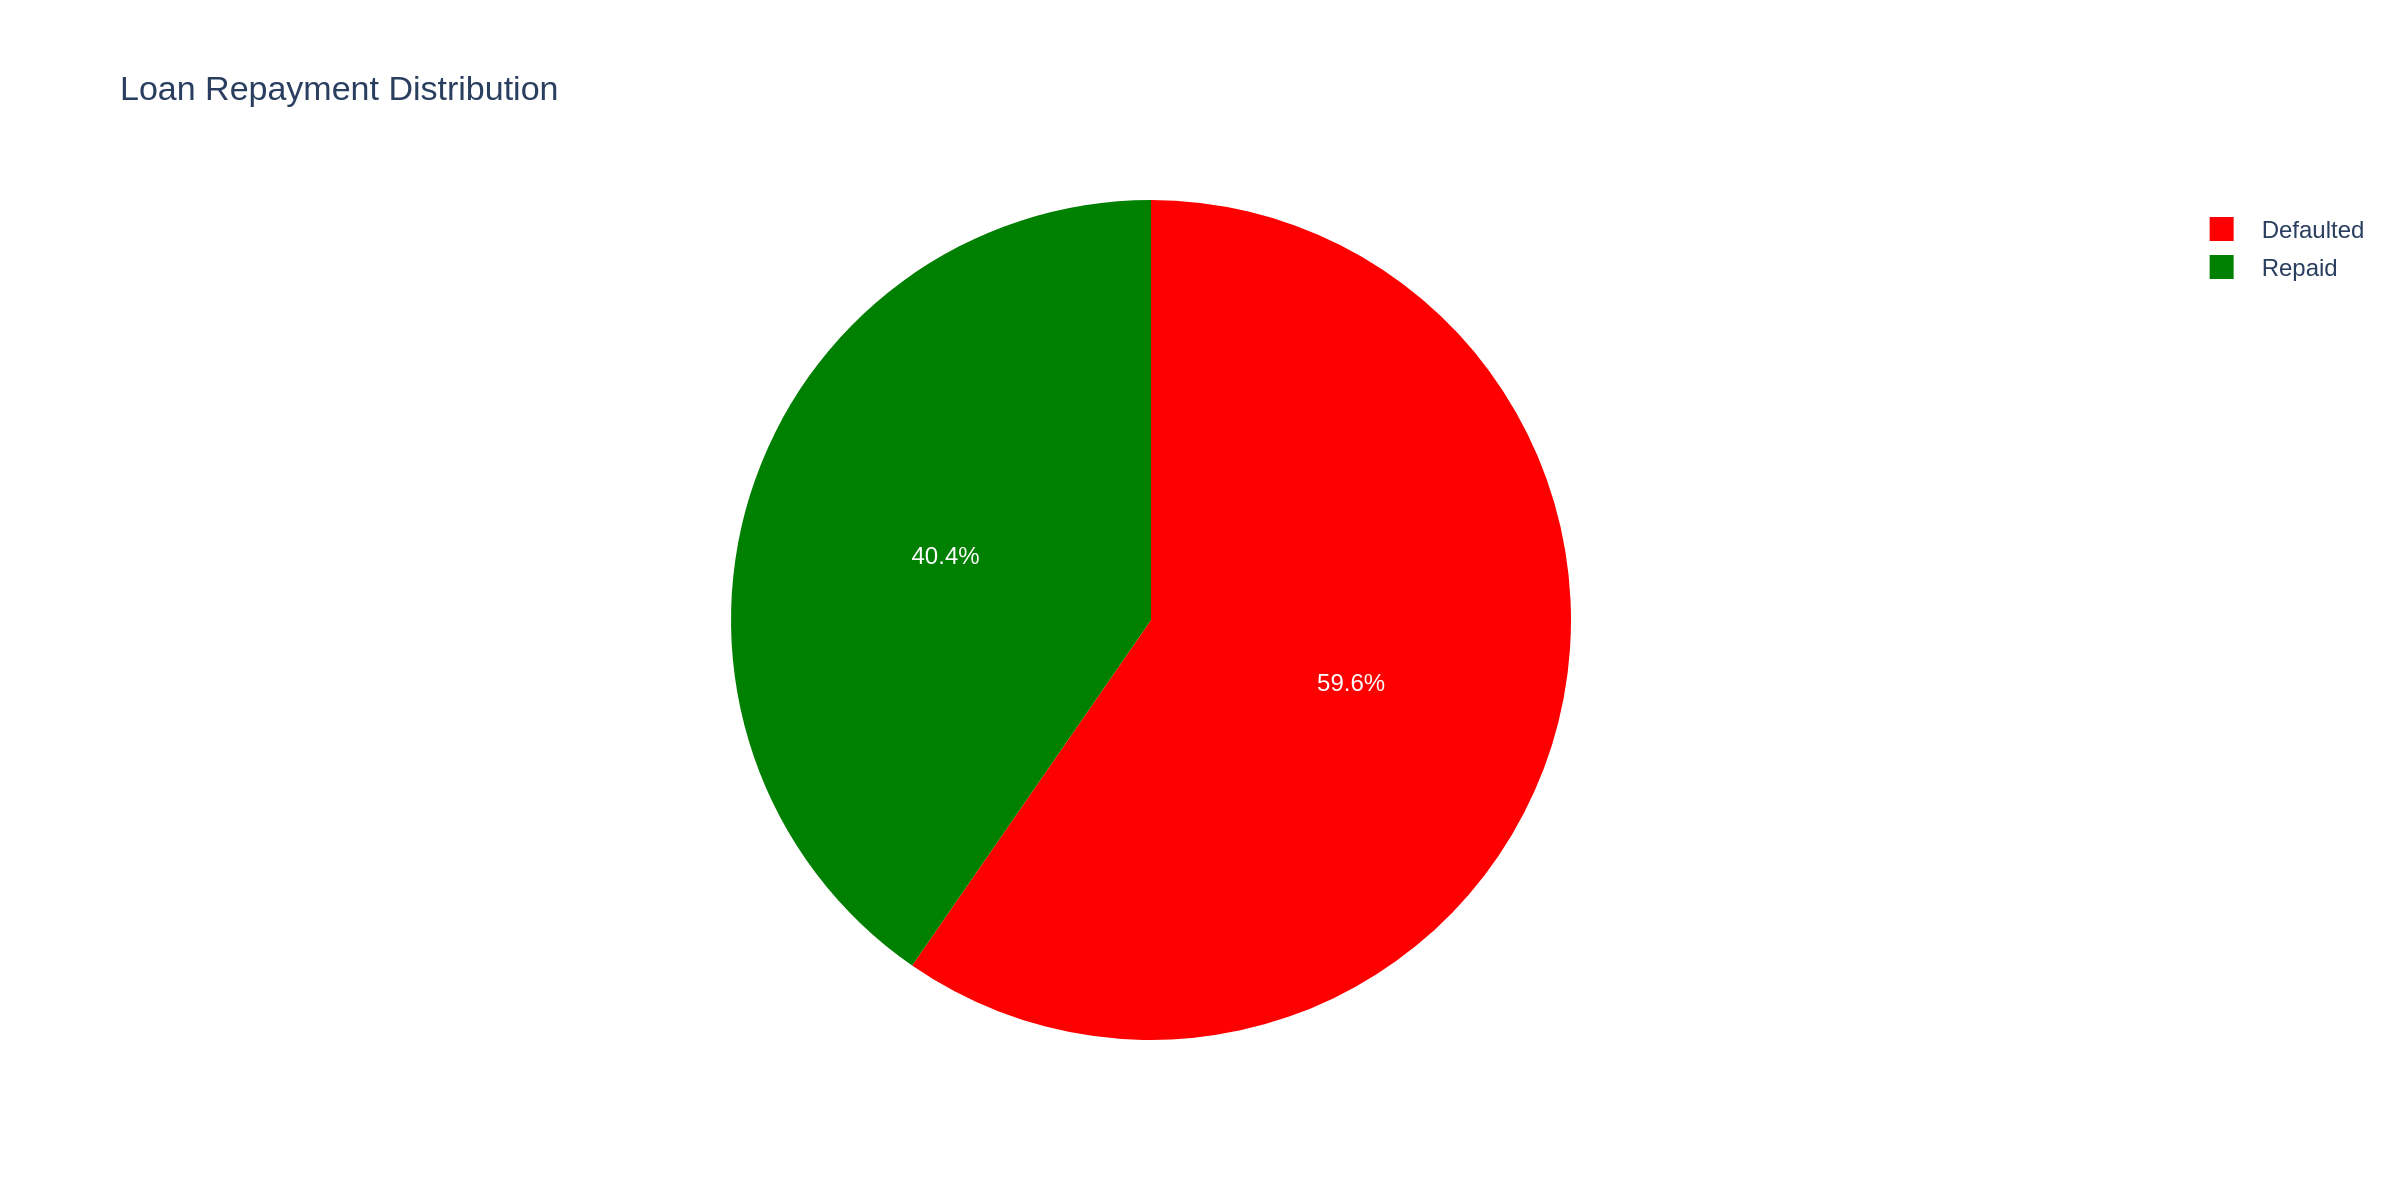

In [ ]:
#Create the chart
fig1 = px.pie(
    loan_counts,
    names='loan_repaid',
    values='count',
    title='Loan Repayment Distribution',
    color = 'loan_repaid',
    color_discrete_map={'Defaulted': 'red', 'Repaid': 'green'}
)

#fig1.show()
show_chart(fig1)

**Key Finding:** *Nearly 60% of funded loans defaulted, meaning that MoneyLion loses money on more than half of its loans. Thus, accurately identifying risky applicants upfront is critical to reducing this loss rate.*

####Repayment Rate by Payment Frequency

In [ ]:
#Calculate repayment rate per frequency group
freq_repayment = df_loan.groupby('payFrequency')['loan_repaid'].mean().reset_index()

In [ ]:
#Rename columns (variables)
freq_repayment.columns = ['payFrequency', 'repayment_rate']

In [ ]:
#Map codes to labels
freq_repayment['payFrequency'] = freq_repayment['payFrequency'].map({
    'B' : 'Biweekly',
    'I' : 'Irregular',
    'M' : 'Monthly',
    'S' : 'Semi-monthly',
    'W' : 'Weekly'
})

In [ ]:
#Sort from highest to lowest
freq_repayment = freq_repayment.sort_values('repayment_rate', ascending=False)

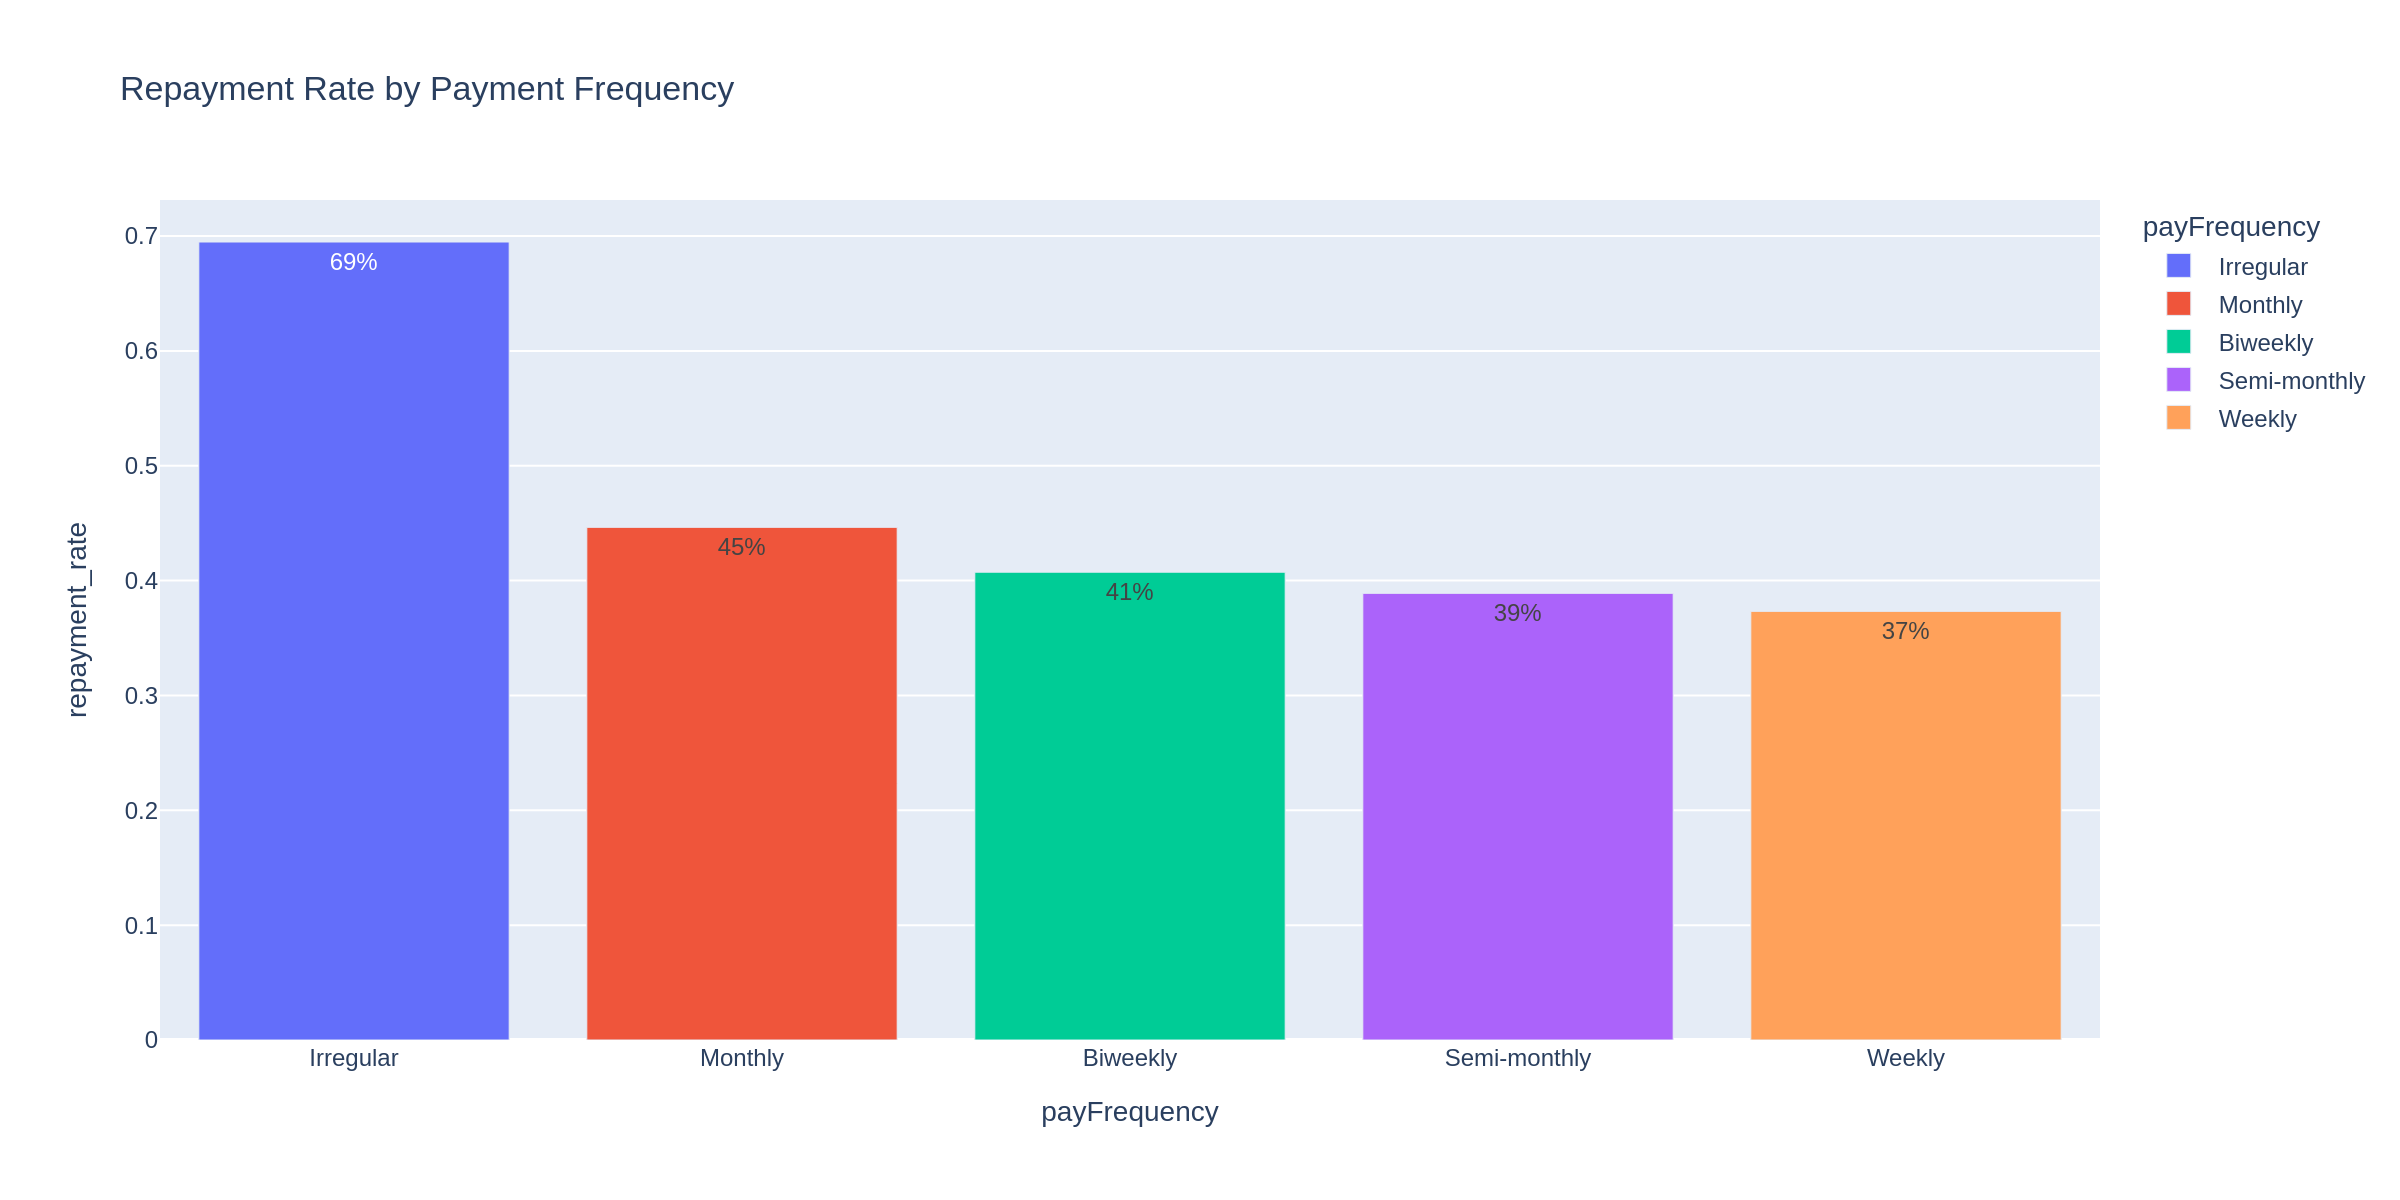

In [ ]:
#Create the chart
fig2 = px.bar(
    freq_repayment,
    x='payFrequency',
    y='repayment_rate',
    title='Repayment Rate by Payment Frequency',
    color='payFrequency',
    color_continuous_scale='RdYlGn',
    text_auto='.0%'
)

#fig2.show()
show_chart(fig2)

**Key Finding:** *Borrowers on irregular payment schedules repay at nearly double the rate of weekly payers (69% vs 37%). Weekly payers are the highest risk group, which is an indicator or likelihood of living paycheck to paycheck with little financial buffer.*

####Repayment Rate by Lead Type

In [ ]:
#Calculate repayment rate / lead type
lead_repayment = df_loan.groupby('leadType')['loan_repaid'].mean().reset_index()

In [ ]:
#Rename columns (variables)
lead_repayment.columns = ['leadType', 'repayment_rate']

In [ ]:
#Sort from lowest to highest
lead_repayment = lead_repayment.sort_values('repayment_rate', ascending=True)

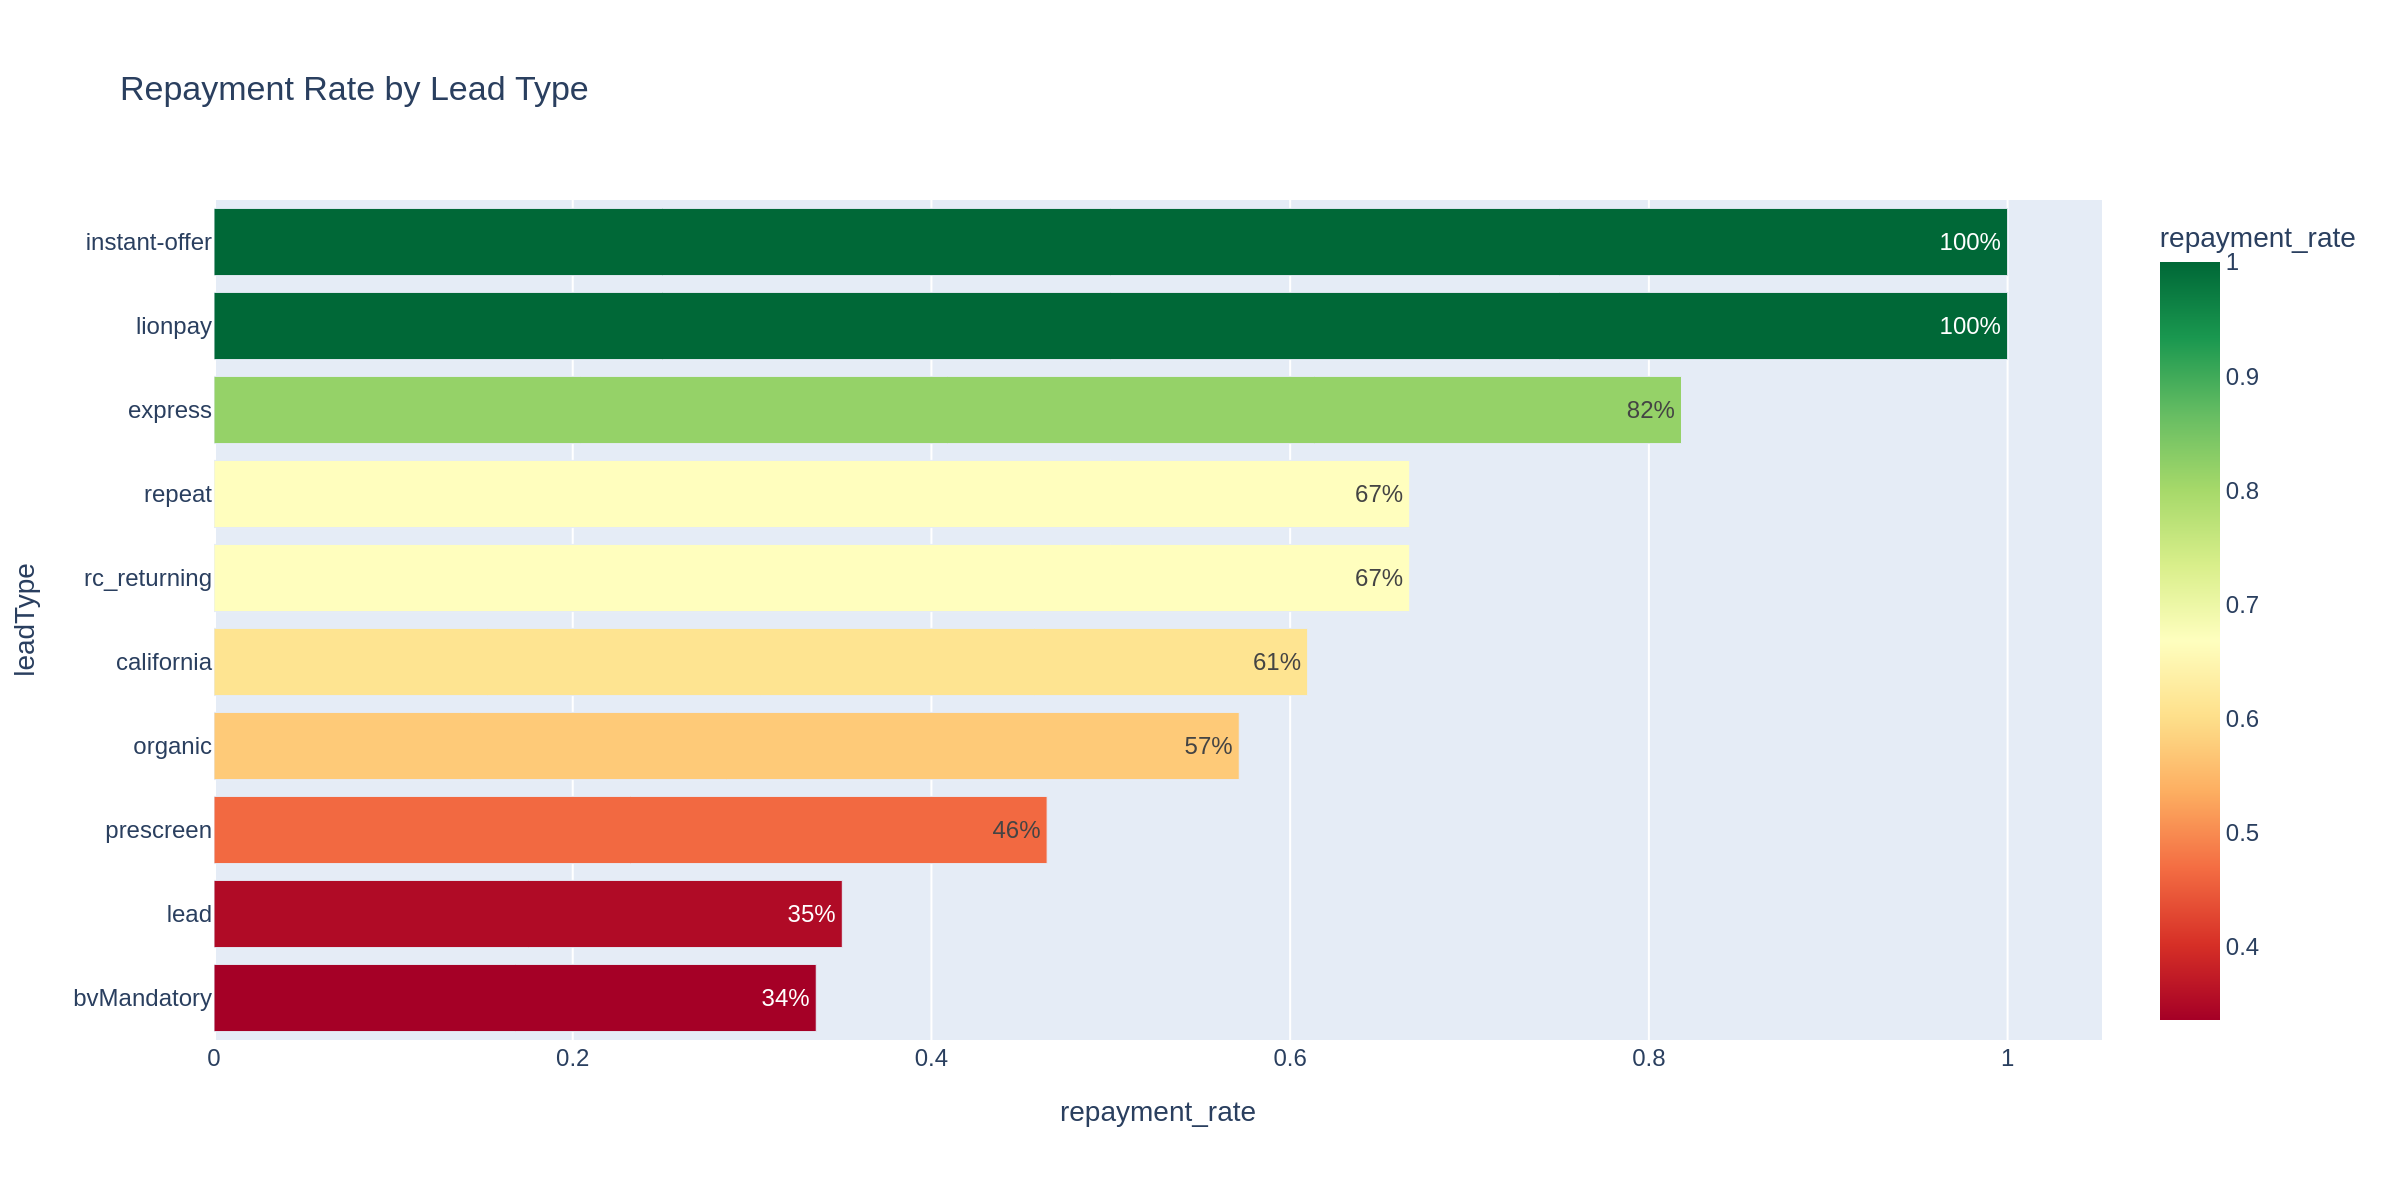

In [ ]:
#Create the chart
fig3 = px.bar(
    lead_repayment,
    x='repayment_rate',
    y='leadType',
    orientation='h',
    title='Repayment Rate by Lead Type',
    color='repayment_rate',
    color_continuous_scale='RdYlGn',
    text_auto='.0%'
)

#fig3.show()
show_chart(fig3)

**Key Finding:** *Instant-offer and LionPay customers repay 100% of the time, while bought leads (bvMandatory, lead) repay less than 35% of the time. This shows that acquiring customers through trusted channels is significantly safer than purchasing leads.*

####Loan Amount Distribution

In [ ]:
#Labels for Defaulted (0) and Repaid (1) loans
df_loan['repayment_label'] = df_loan['loan_repaid'].map({0: 'Defaulted', 1: 'Repaid'})

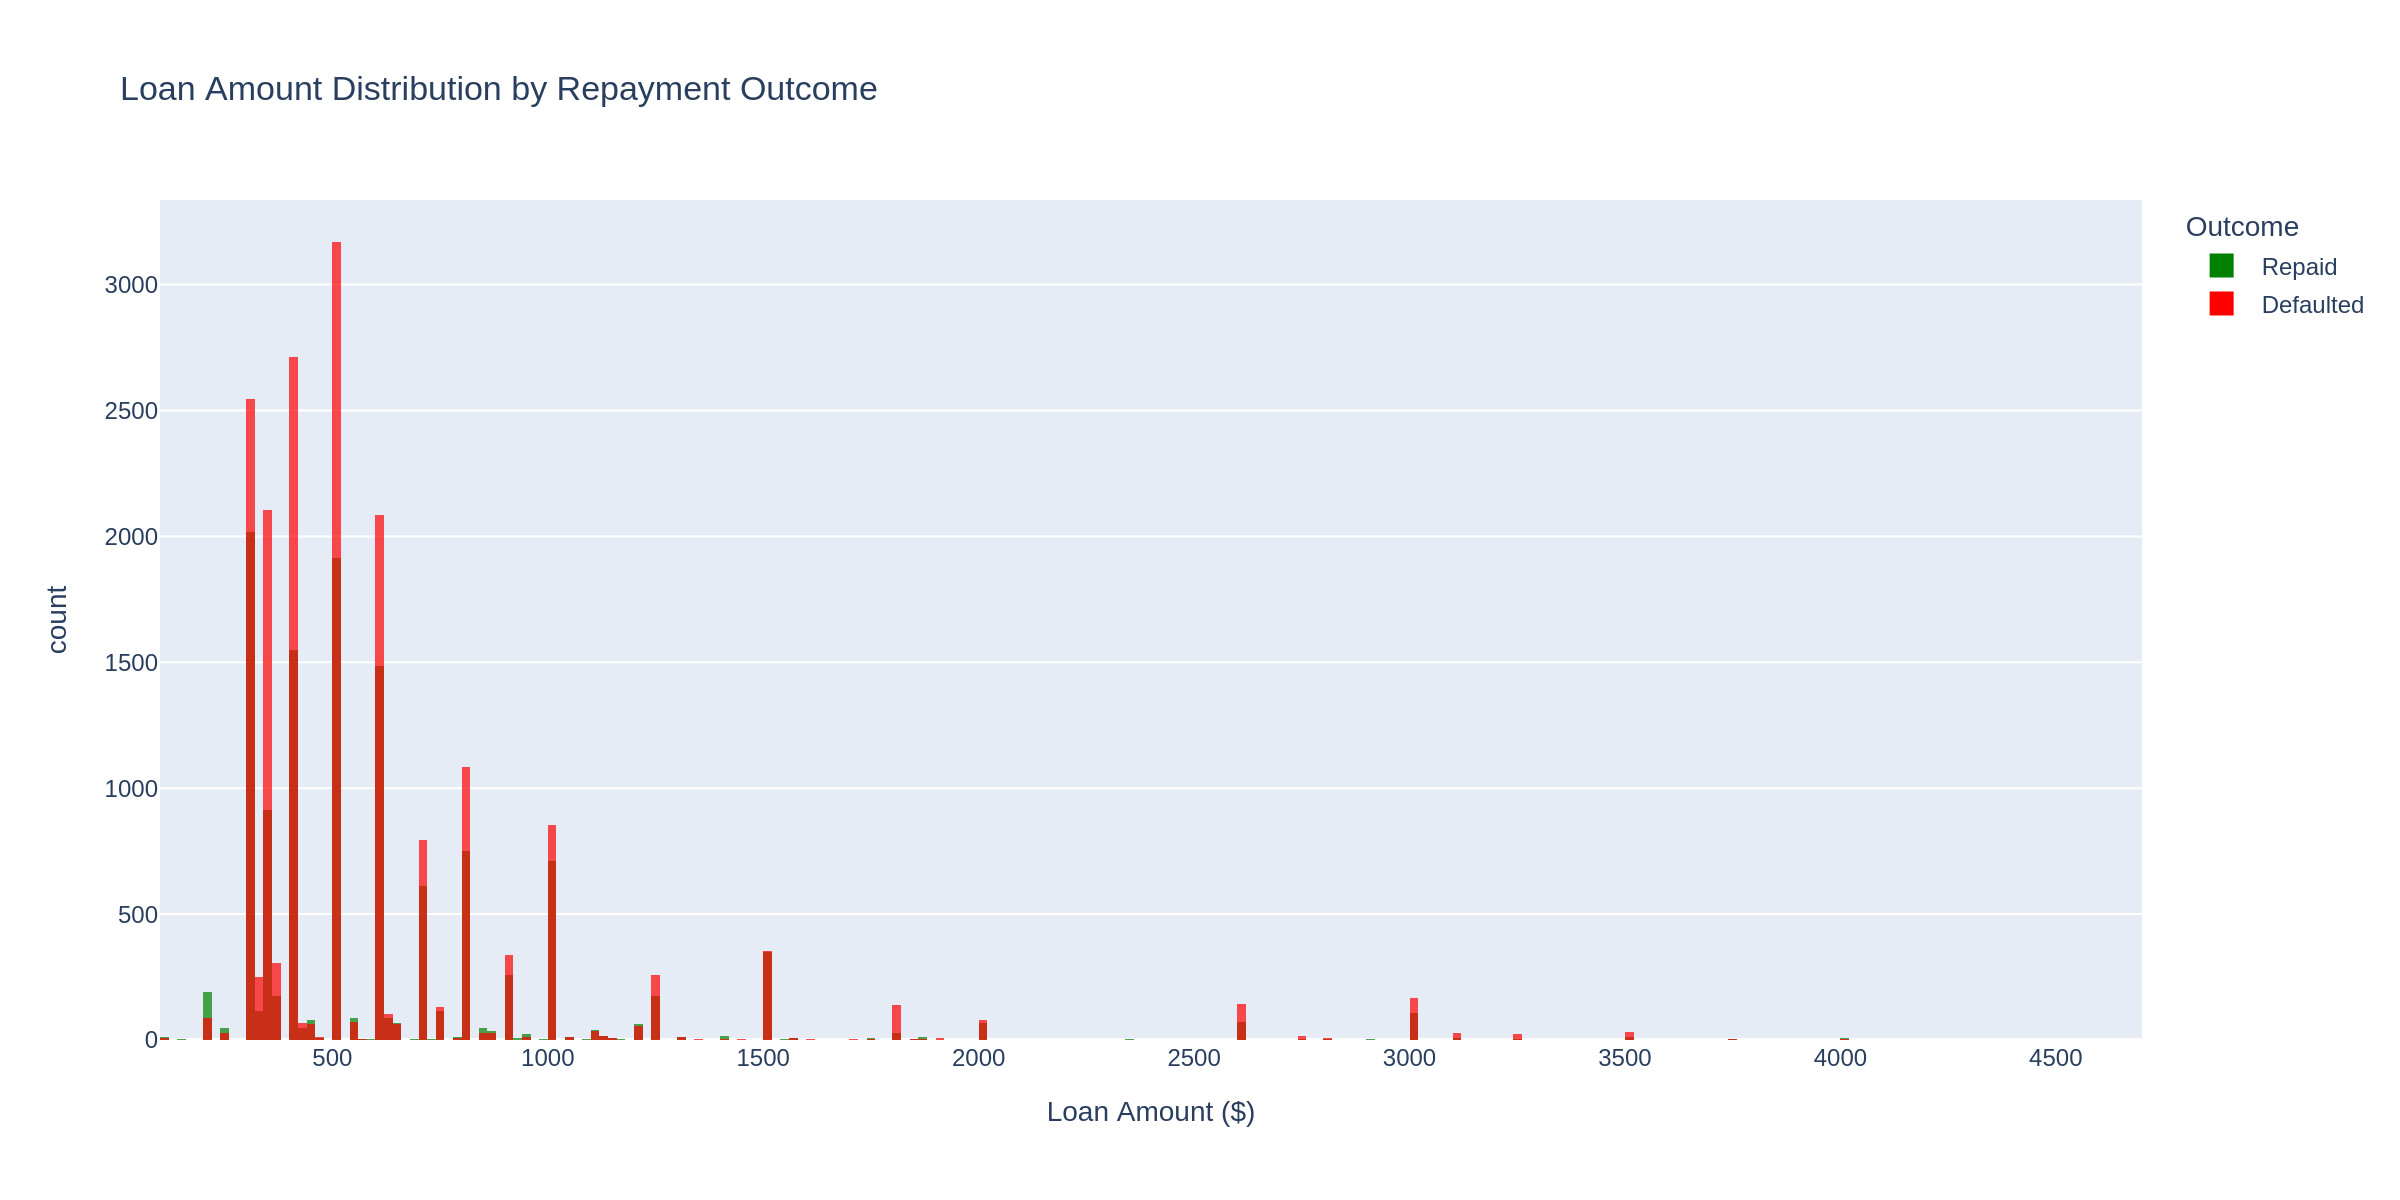

In [ ]:
#Histogram of loan amounts split by repayment outcome
fig4 = px.histogram(
    df_loan,
    x='loanAmount',
    color='repayment_label',
    title='Loan Amount Distribution by Repayment Outcome',
    barmode='overlay',
    opacity=0.7,
    color_discrete_map={'Defaulted': 'red', 'Repaid': 'green'},
    labels={'repayment_label': 'Outcome','loanAmount': 'Loan Amount ($)'}
)

#fig4.show()
show_chart(fig4)

**Key Finding:** *Most loans fall between USD300 to USD600 and defaults mainly concentrate in this range because it's the most common loan size. Larger loans like those above USD1,500 are rare, suggesting MoneyLion already limits exposure on high-value loans.*

####Top 10 States by Loan Volume

In [ ]:
#Get repayment rate & count per state
state_stats = df_loan.groupby('state')['loan_repaid'].agg(['mean', 'count']).reset_index()

In [ ]:
#Rename columns (variables)
state_stats.columns = ['state', 'repayment_rate', 'loan_count']

In [ ]:
#Keep states with loans >= 100
state_stats = state_stats[state_stats['loan_count'] >= 100]

In [ ]:
#Keep only top 10 states by loan volume
top10_states = state_stats.sort_values('loan_count', ascending=False).head(10)
print(top10_states)

   state  repayment_rate  loan_count
28    OH        0.417246        5752
12    IL        0.543453        4223
35    TX        0.294710        2382
39    WI        0.539812        2336
20    MO        0.372506        1804
18    MI        0.450647        1469
13    IN        0.477070        1461
22    NC        0.509677        1395
7     FL        0.279123        1322
3     CA        0.337974        1293


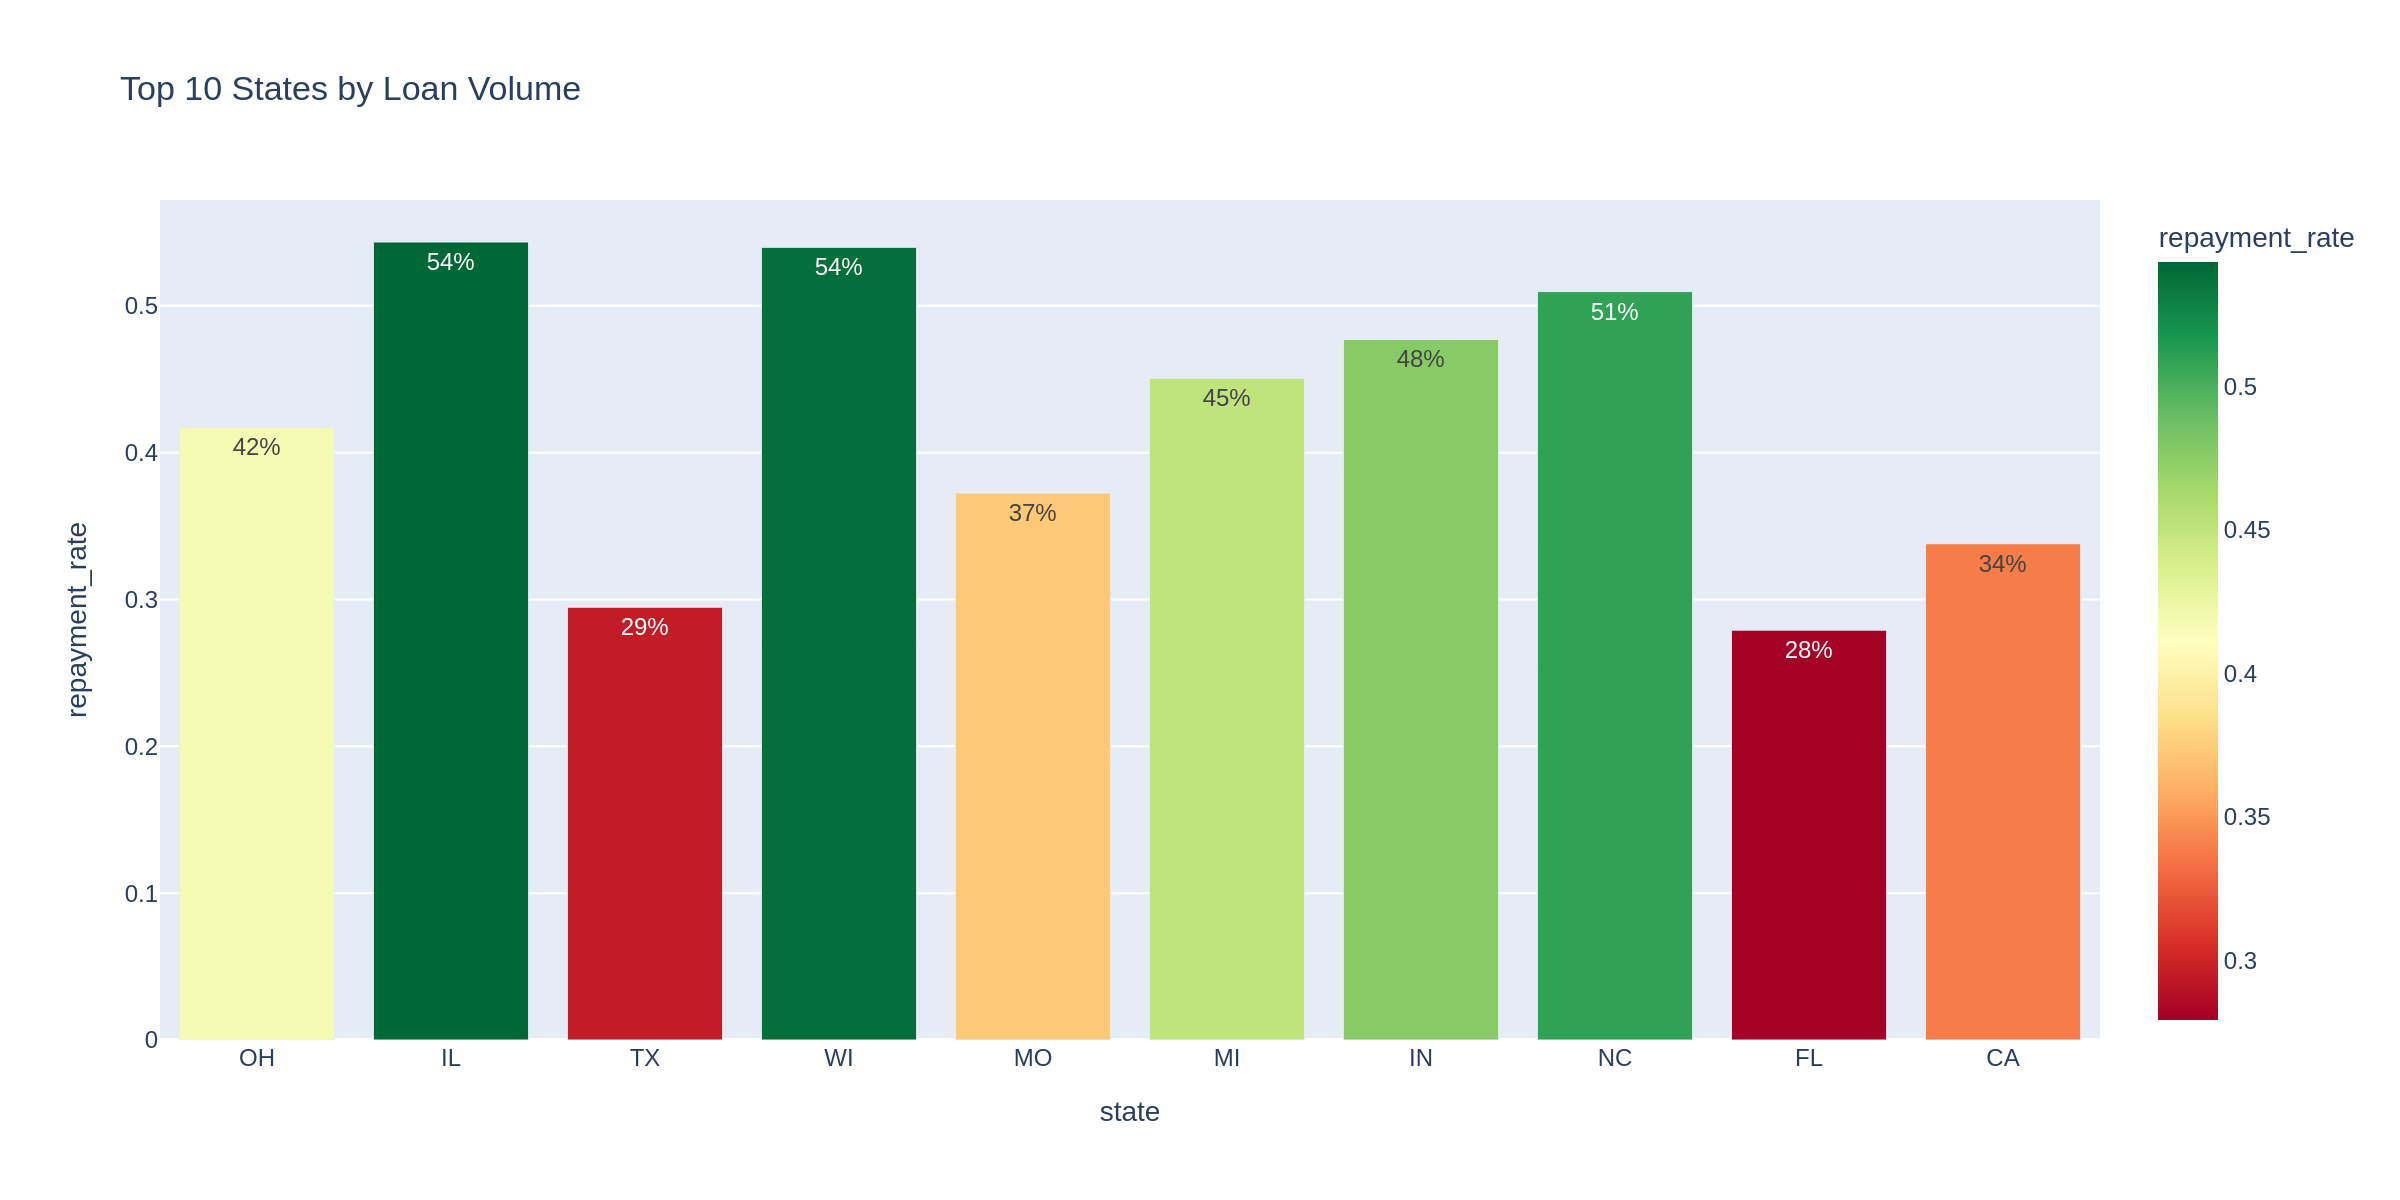

In [ ]:
#Create the chart
fig5 = px.bar(
    top10_states,
    x='state',
    y='repayment_rate',
    title='Top 10 States by Loan Volume',
    color='repayment_rate',
    color_continuous_scale='RdYlGn',
    text_auto='.0%',
    hover_data=['loan_count']
)

#fig5.show()
show_chart(fig5)

**Key Finding:** *Illinois and Wisconsin show the strongest repayment rates (54%) among high-volume states, while Texas and Florida are the riskiest (under 30%). State-level risk should be factored into underwriting decisions.*

##Payment Dataset

Now EDA of the payment history file. Each row here represents one payment attempt for a loan. Understanding payment behaviour can show signals for predicting repayment.

####Explore dataset

Check the size, structure and missing values of the payment dataset before extracting features from it.

In [ ]:
df_payment.head(10)

,loanId,installmentIndex,isCollection,paymentDate,principal,fees,paymentAmount,paymentStatus,paymentReturnCode
0,LL-I-00000021,1,False,2014-12-19T05:00:00,22.33,147.28,169.61,Checked,NaN
1,LL-I-00000021,2,False,2015-01-02T05:00:00,26.44,143.17,169.61,Checked,NaN
2,LL-I-00000021,3,False,2015-01-16T05:00:00,31.30,138.31,169.61,Checked,NaN
3,LL-I-00000021,4,False,2015-01-30T05:00:00,37.07,132.54,169.61,Checked,NaN
4,LL-I-00000021,5,False,2015-02-13T05:00:00,43.89,125.72,169.61,Checked,NaN
5,LL-I-00000021,6,False,2015-02-27T05:00:00,51.97,117.64,169.61,Checked,NaN
6,LL-I-00000021,7,False,2015-03-13T04:00:00,61.54,108.07,169.61,Checked,NaN
7,LL-I-00000021,8,False,2015-03-27T04:00:00,72.87,96.74,169.61,Checked,NaN
8,LL-I-00000021,9,False,2015-04-10T04:00:00,86.29,83.32,169.61,Checked,NaN
9,LL-I-00000021,10,False,2015-04-24T04:00:00,102.17,67.44,169.61,Rejected,R01


In [ ]:
df_payment.shape

(689364, 9)

In [ ]:
df_payment.isnull().sum()

,0
loanId,0
installmentIndex,0
isCollection,0
paymentDate,0
principal,0
fees,0
paymentAmount,0
paymentStatus,164057
paymentReturnCode,657831


In [ ]:
df_payment['paymentStatus'].value_counts()

,count
paymentStatus,
Cancelled,270334
Checked,209621
Rejected,32330
Pending,9241
Skipped,3761
Rejected Awaiting Retry,18
Returned,1
Complete,1


####Checks payment success/not

Create a simple column marking each payment attempt as successful (1) or not (0). This will allow the calculation of the success rate per loan later.


In [ ]:
#Create a new column, 1 if payment succeed, 0 if not
df_payment['is_successful'] = (df_payment['paymentStatus'] == 'Checked').astype(int)

In [ ]:
df_payment[['paymentStatus', 'is_successful']].head(10)

,paymentStatus,is_successful
0,Checked,1
1,Checked,1
2,Checked,1
3,Checked,1
4,Checked,1
5,Checked,1
6,Checked,1
7,Checked,1
8,Checked,1
9,Rejected,0


####Group & Summarise

Combine the payment dataset from 1 row per payment into 1 row per loan. This will give 3 new features:

- **total_payments** *(how many payment attempts were made)*
- **success_rate** *(what fraction of payments succeeded)*
- **ever_in_collection** *(was the borrower ever placed on a collection plan?)*

In [ ]:
#Summarise into one row per loan
payment_features = df_payment.groupby('loanId').agg(
    total_payments = ('paymentStatus', 'count'),
    success_rate = ('is_successful', 'mean'),
    ever_in_collection = ('isCollection', 'max') #Custom made collection plan
).reset_index()

In [ ]:
print(payment_features.shape)
print(payment_features.head(10))
print(payment_features.isnull().sum())

(39952, 4)
          loanId  total_payments  success_rate  ever_in_collection
0  LL-I-00000021              13      0.923077                True
1  LL-I-00000231              12      0.100000               False
2  LL-I-00000238              12      0.437500               False
3  LL-I-00000308              12      0.045455               False
4  LL-I-00000355              12      0.000000               False
5  LL-I-00000419              13      0.095238               False
6  LL-I-00000614              12      0.000000               False
7  LL-I-00001902              12      1.000000               False
8  LL-I-00002130              12      0.157895               False
9  LL-I-00002148              12      0.045455               False
loanId                0
total_payments        0
success_rate          0
ever_in_collection    0
dtype: int64


####Visualisations

The following charts explore overall payment health, collection plan usage, typical loan repayment journey length, and the most common reasons for payment failures.

#####Payment Status Breakdown
*Out of all payment attempts, how many are successful?*

In [ ]:
#Count each payment status
payment_status_counts = df_payment['paymentStatus'].value_counts().reset_index()

In [ ]:
#Rename columns (variables)
payment_status_counts.columns = ['paymentStatus', 'count']

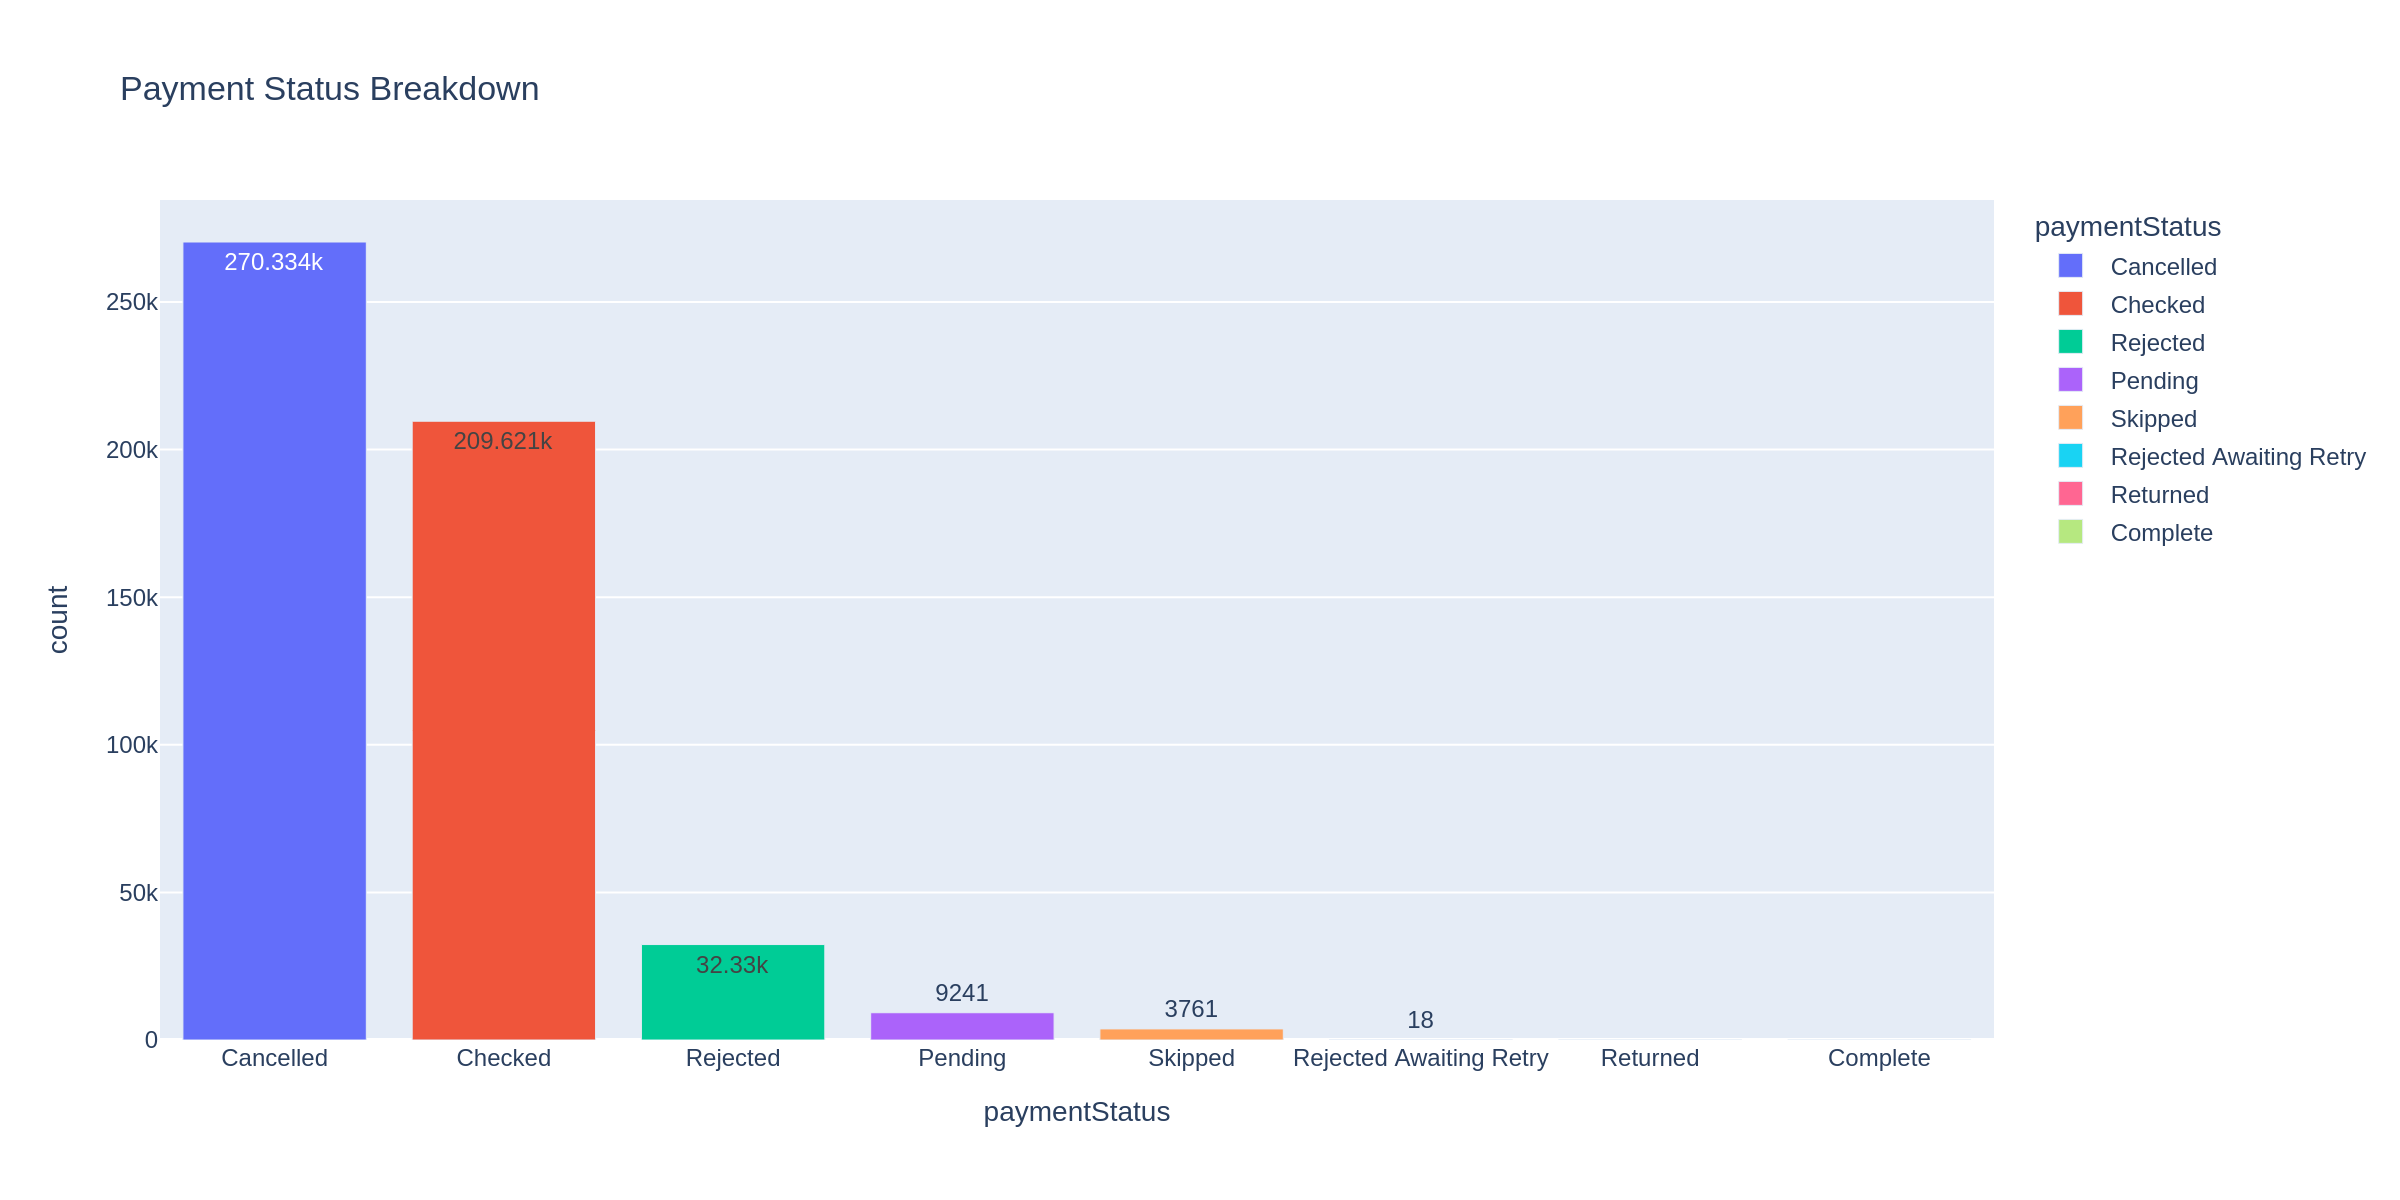

In [ ]:
#Create bar chart
fig_p1 = px.bar(
    payment_status_counts,
    x='paymentStatus',
    y='count',
    title='Payment Status Breakdown',
    color='paymentStatus',
    text_auto=True
)

#fig_p1.show()
show_chart(fig_p1)

**Key Finding:** *Cancelled payments (270k) outnumber successful ones (209k), suggesting many loans were closed or defaulted before all payments were collected. Only 6% of all payment attempts were outright rejected, meaning most failures come from early loan termination, not payment bouncing.*

#####Collection Plan Usage
*How many loans went into collection plan vs paid normally*

In [ ]:
#Count how many payment records are collection vs normal
collection_counts = df_payment['isCollection'].value_counts().reset_index()

In [ ]:
#Rename columns (variables)
collection_counts.columns = ['isCollection', 'count']

In [ ]:
#Replace True/False with labels
collection_counts['isCollection'] = collection_counts['isCollection'].map({True: 'Collection Plan', False: 'Normal Payment'})

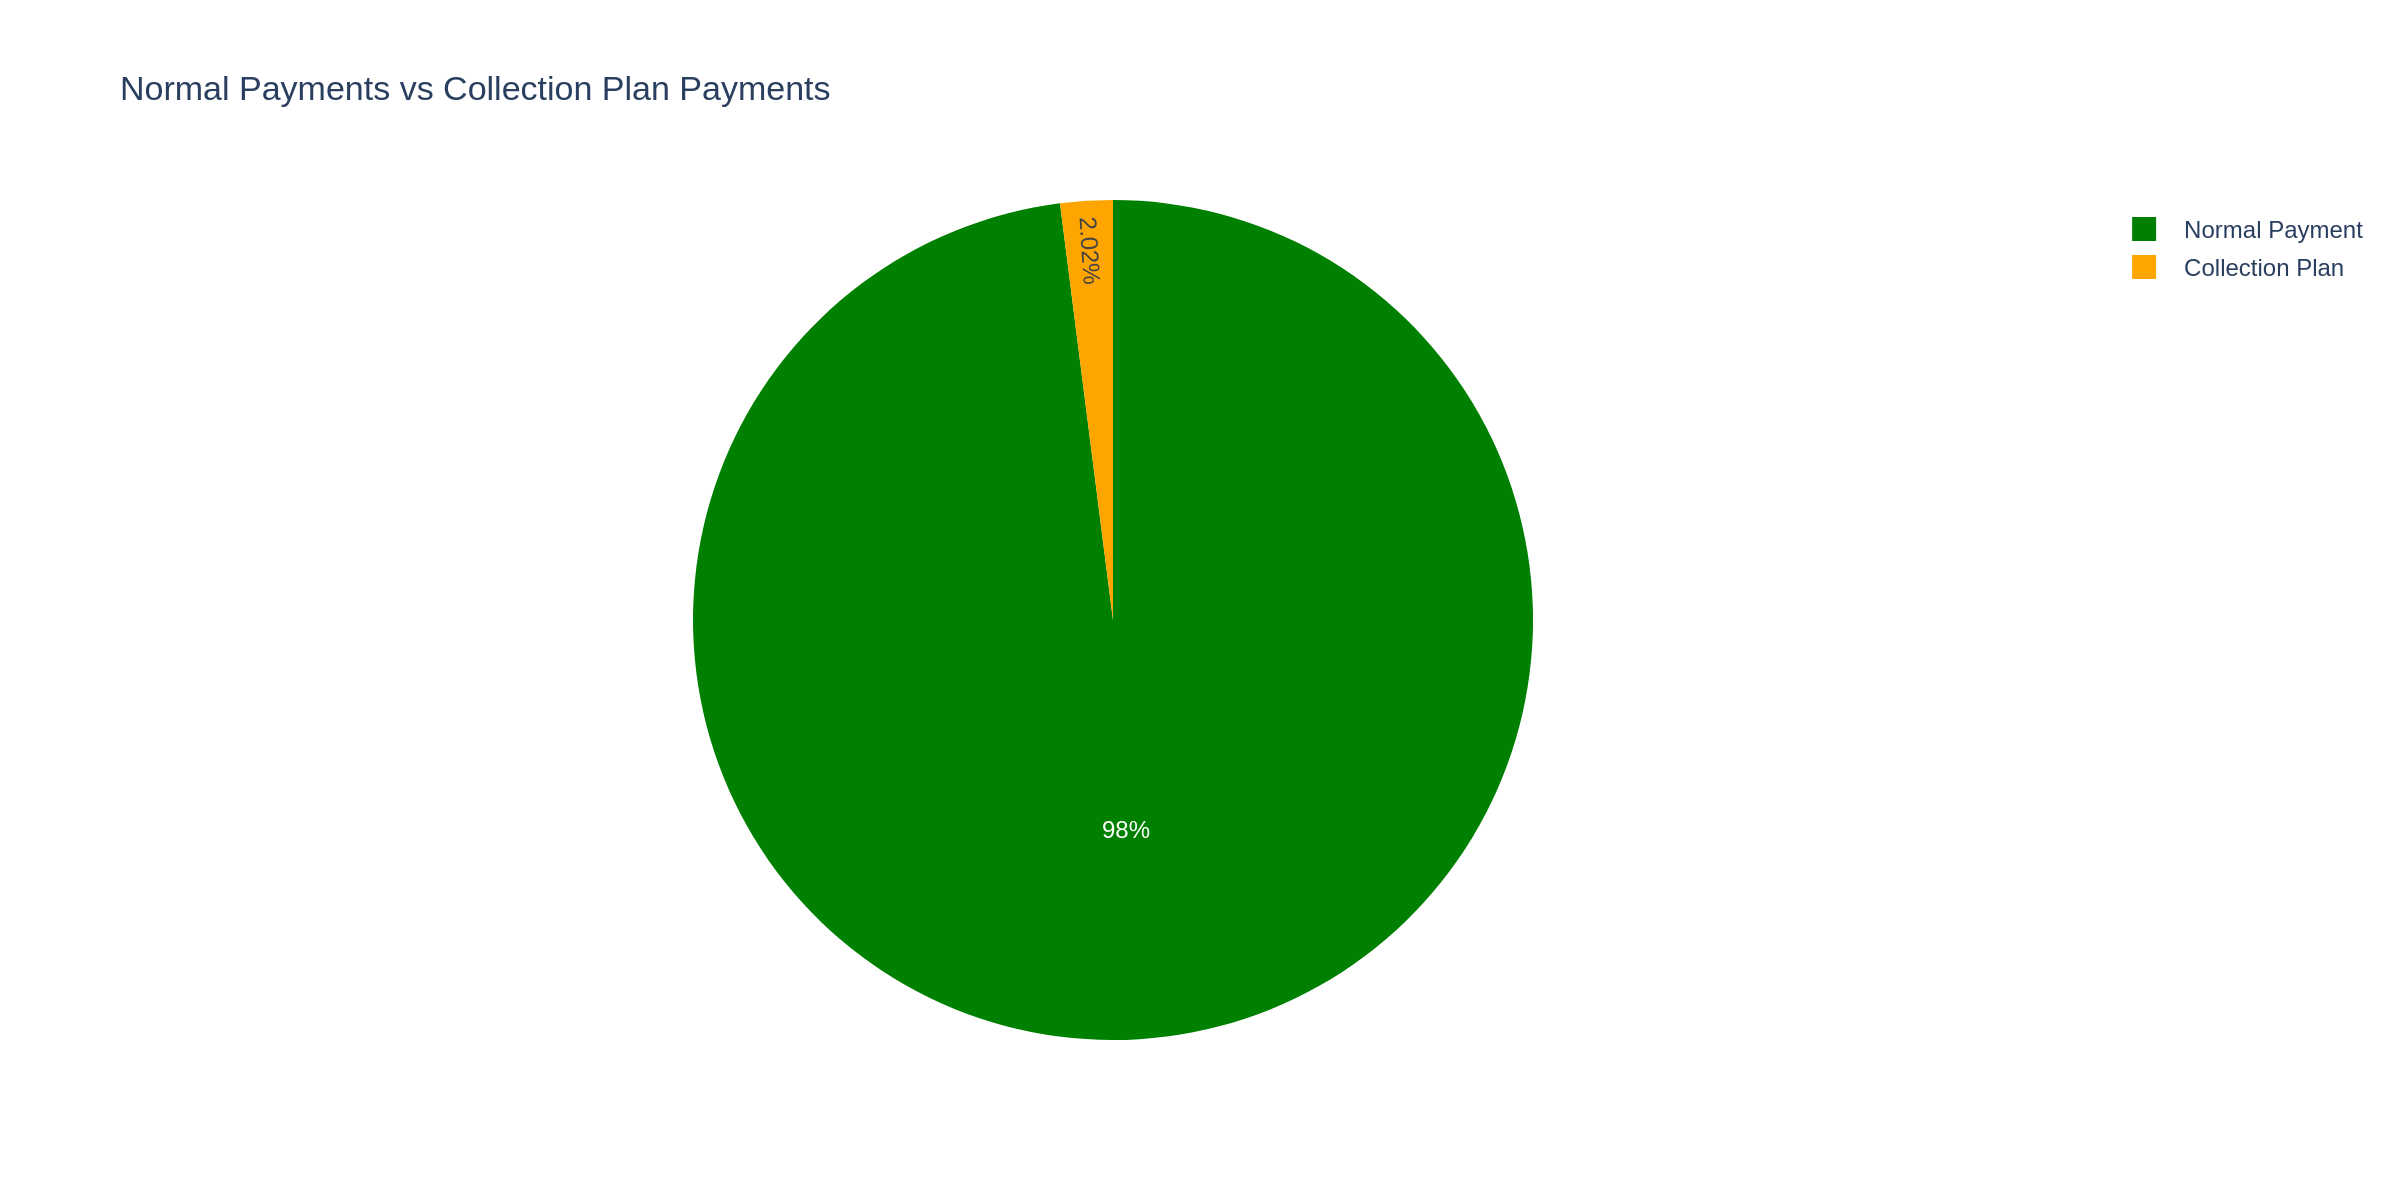

In [ ]:
#Create pie chart
fig_p2 = px.pie(
    collection_counts,
    names='isCollection',
    values='count',
    title='Normal Payments vs Collection Plan Payments',
    color='isCollection',
    color_discrete_map={'Collection Plan': 'orange', 'Normal Payment': 'green'}
)

#fig_p2.show()
show_chart(fig_p2)

**Key Finding:** *Only 2% of all payment records involve a collection plan, meaning that most borrowers either pay normally or stop paying altogether. When a collection plan is triggered, it is a strong signal the borrower is in serious financial difficulty.*

#####Distribution of Payments per Loan
*Shows how many payment attempts each loan has*

In [ ]:
#Count how many payment rows exist per loan
payments_per_loan = df_payment.groupby('loanId')['installmentIndex'].count().reset_index()

In [ ]:
#Rename columns (variables)
payments_per_loan.columns = ['loanId', 'num_payments']

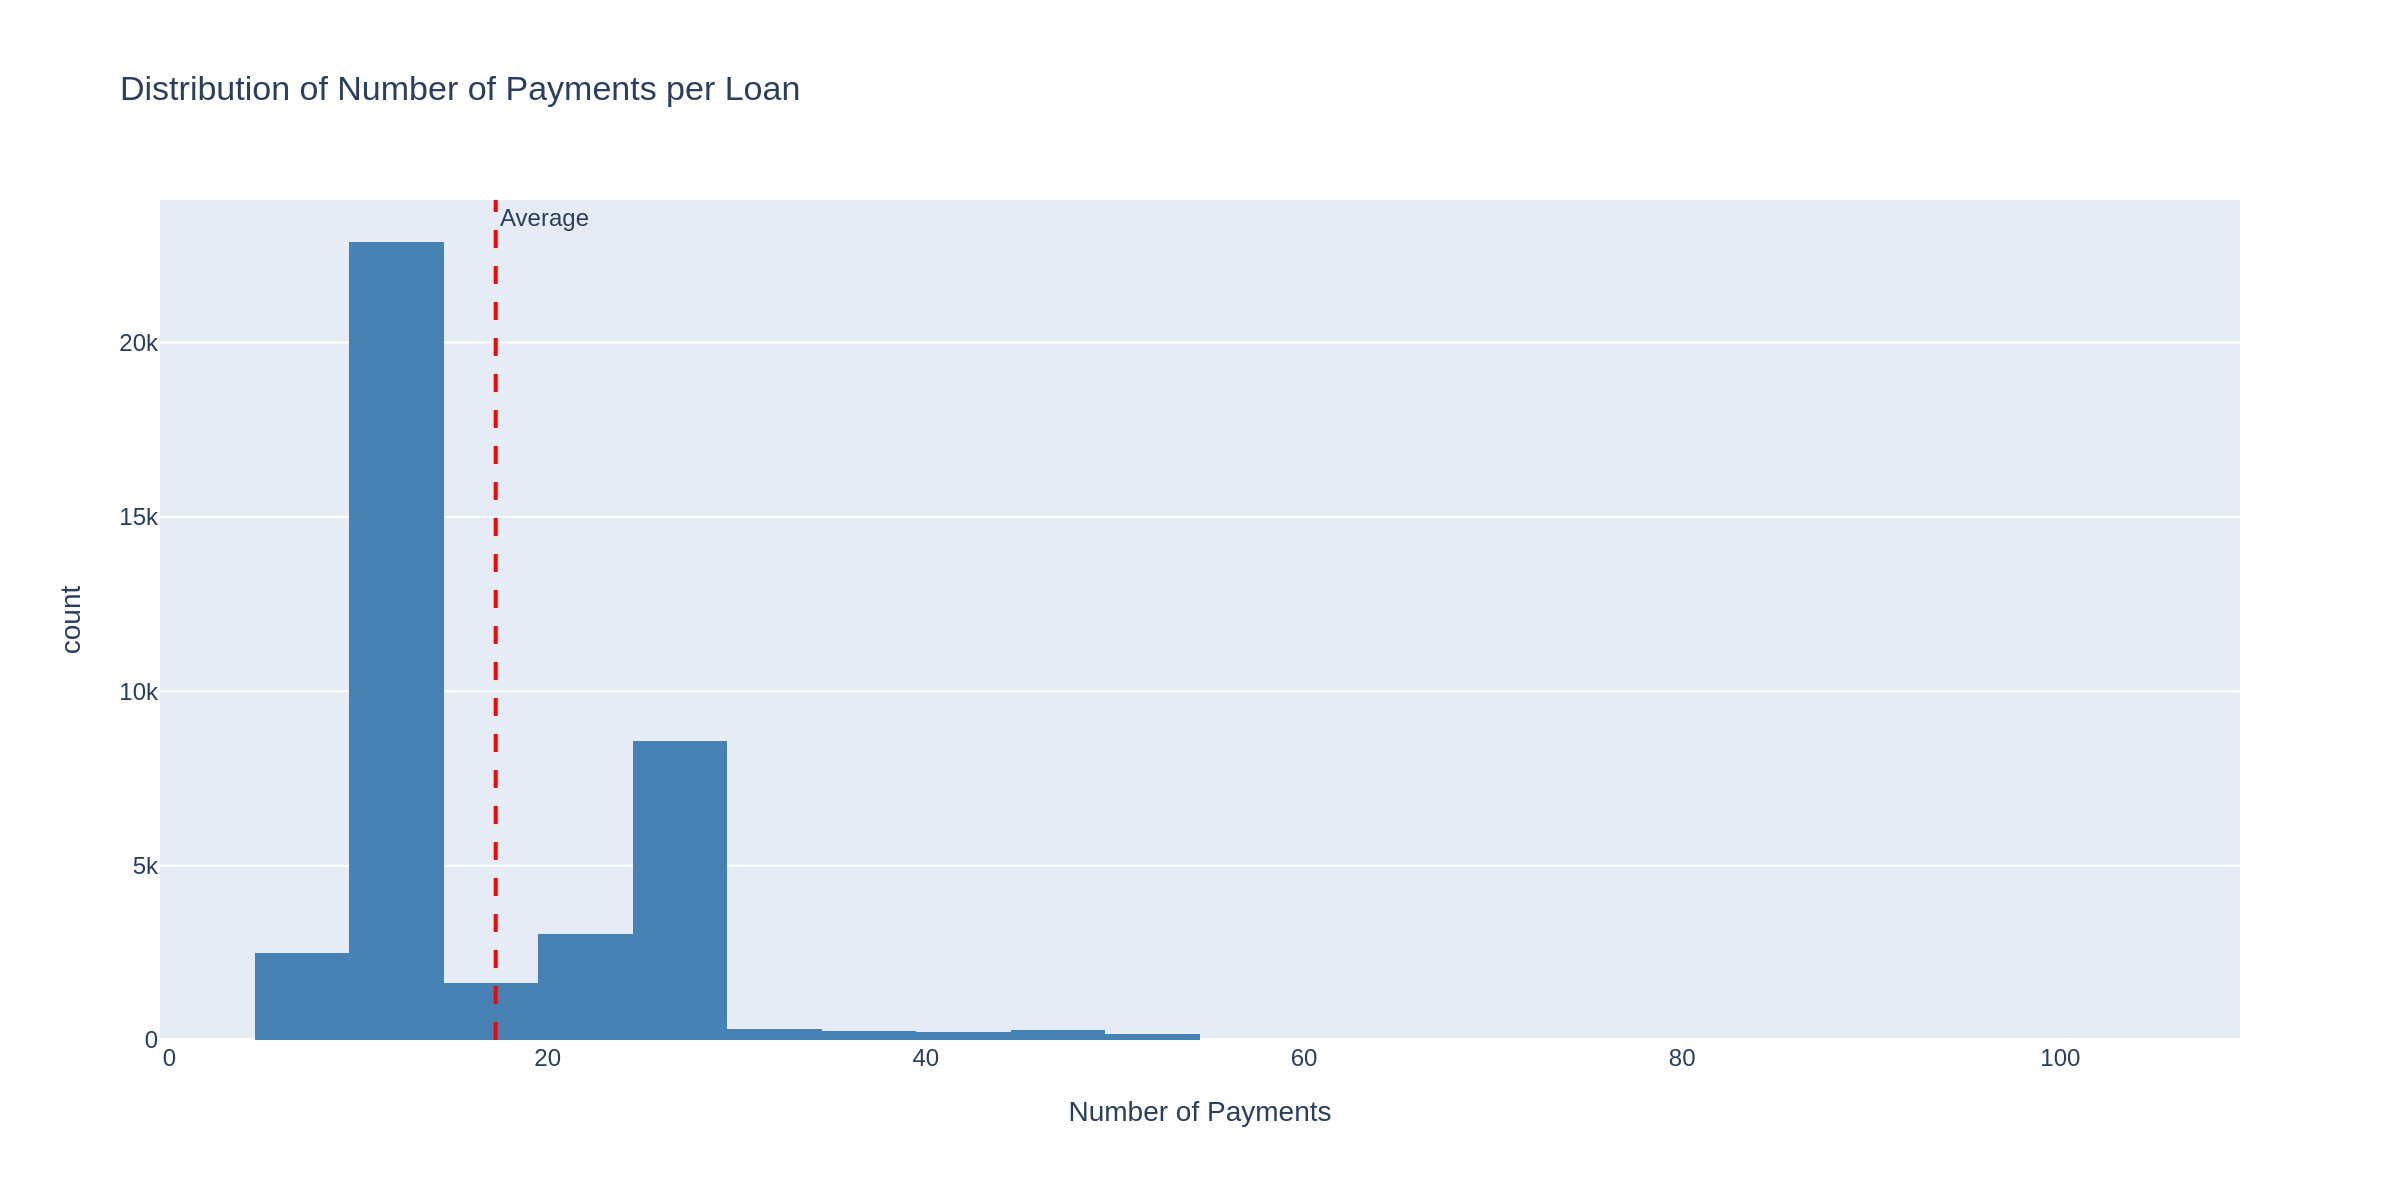

In [ ]:
#Create histogram
fig_p3 = px.histogram(
    payments_per_loan,
    x='num_payments',
    title='Distribution of Number of Payments per Loan',
    nbins=30,
    color_discrete_sequence=['steelblue'],
    labels={'num_payments': 'Number of Payments'}
)

#Add line to show the average
fig_p3.add_vline(
    x=payments_per_loan['num_payments'].mean(),
    line_dash='dash',
    line_color='red',
    annotation_text='Average'
)

#fig_p3.show()
show_chart(fig_p3)

**Key Finding:** *Most loans have between 10 – 15 payment, with an average of around 17. Only a small number of loans show have more than 40 payments, these are likely cases where MoneyLion repeatedly tried to recover money from non-paying borrowers.*

#####Top Rejected Payment Reasons
*Show reasons why payments rejected*

In [ ]:
#Show only rejected payments that have a return code
rejected_payments = df_payment[(df_payment['paymentStatus'] == 'Rejected') & (df_payment['paymentReturnCode'].notna())]

In [ ]:
#Count each return code
return_code_counts = rejected_payments['paymentReturnCode'].value_counts().reset_index()

In [ ]:
#Rename columns (variables)
return_code_counts.columns = ['returnCode', 'count']

In [ ]:
#Keep top 10 reasons only
return_code_counts = return_code_counts.head(10)

In [ ]:
#Map codes to descriptions
code_desc = {
    'R01': 'Inssufficient Funds',
    'R02': 'Account Closed',
    'R03': 'No Account/Unable to Locate Account',
    'R04': 'Invalid Account Number',
    'R05': 'Unauthorized Debit Entry',
    'R06': 'Returned per ODFI’s Request',
    'R07': 'Authorization Revoked by Customer',
    'R08': 'Payment Stopped or Stop Payment on Item',
    'R09': 'Uncollected Funds',
    'R10': 'Not Authorized',
    'R11': 'Check Truncation Entry Return',
    'R12': 'Branch Sold to Another DFI',
    'R13': 'RDFI not qualified to participate',
    'R14': 'Unable to Continue in that Capacity',
    'R15': 'Beneficiary or Account Holder Deceased',
    'R16': 'Account Frozen',
    'R17': 'File Record Edit Criteria',
    'R20': 'Non-Transaction Account',
    'R21': 'Invalid Company Identification',
    'R22': 'Invalid Individual ID Number',
    'R23': 'Credit Entry Refused by Receiver',
    'R24': 'Duplicate Entry',
    'R29': 'Corporate Customer Advises Not Authorized',
    'R31': 'Permissible Return Entry',
    'R33': 'Return of XCK Entry'
}

return_code_counts['returnCode'] = return_code_counts['returnCode'].map(code_desc).fillna(return_code_counts['returnCode'])

#Sort ascending
return_code_counts = return_code_counts.sort_values('count', ascending=True)

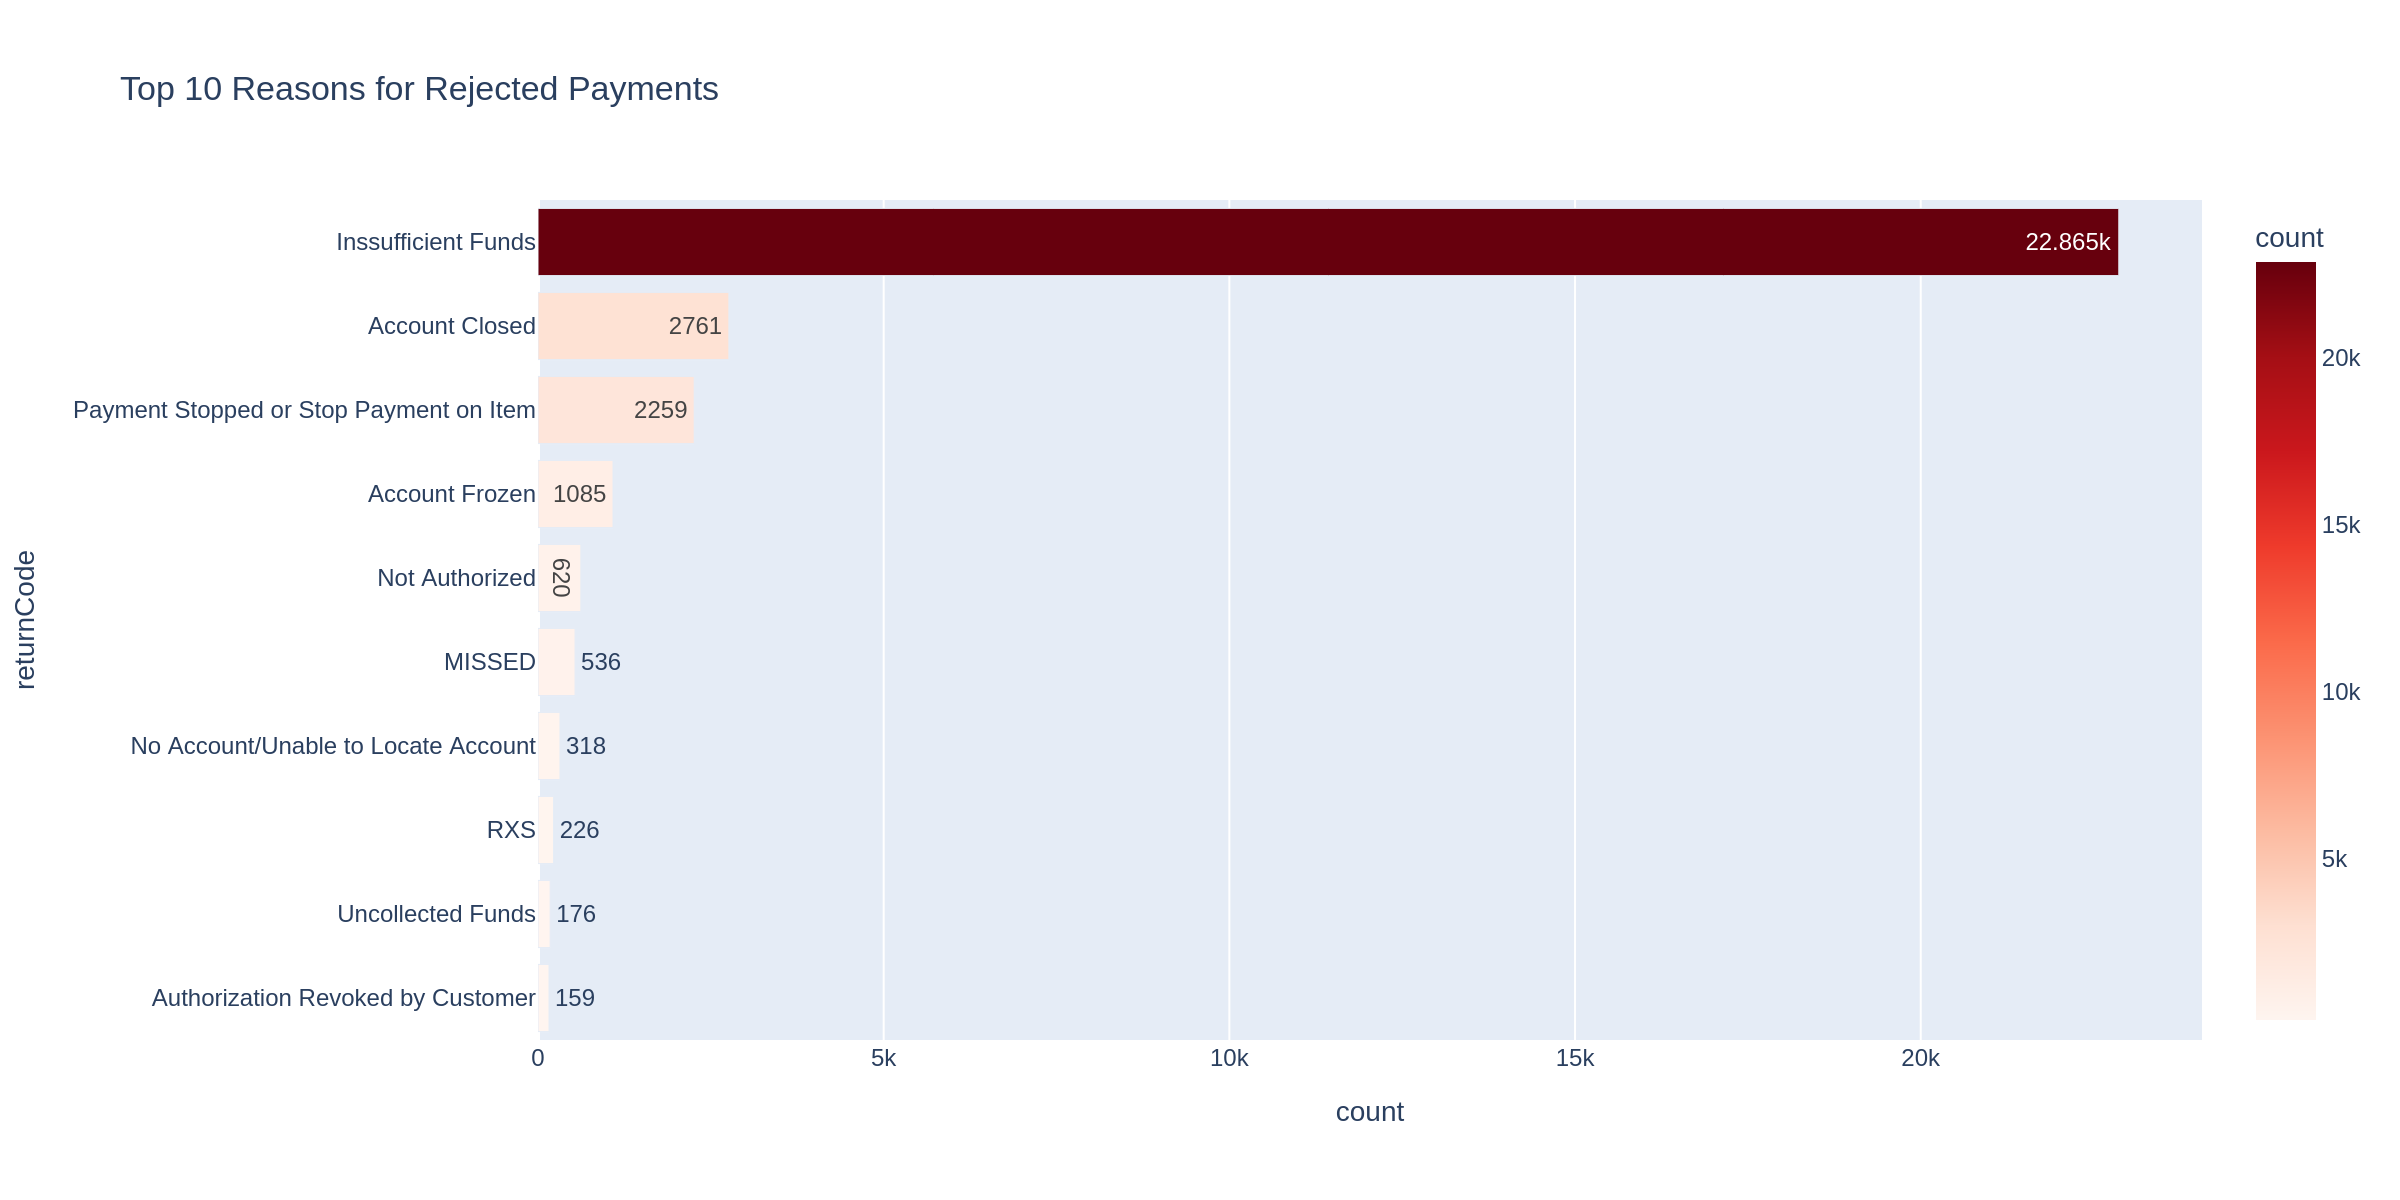

In [ ]:
#Create horizontal bar chart
fig_p4 = px.bar(
    return_code_counts,
    x='count',
    y='returnCode',
    orientation='h',
    title='Top 10 Reasons for Rejected Payments',
    color='count',
    color_continuous_scale='Reds',
    text_auto=True
)

#fig_p4.show()
show_chart(fig_p4)

**Key Finding:** *Insufficient Funds accounts for over 22,865 rejections, which is more than every other reason combined. This strongly suggests most defaulting borrowers run out of money rather than deliberately avoiding repayment, meaning that affordability may be the root cause of loan defaults.*

##Join loan & payment df

Merge the payment summary back into the main loan dataset using `loanId` as the shared key. This adds the 3 engineered payment features to each loan record.

In [ ]:
#Join payment features (columns) into df_loan
df_combined = df_loan.merge(payment_features, on='loanId', how='left')

###Verify join

In [ ]:
#Check rows should be the same as df_loan, with 4 new columns
print(df_combined.shape)

(30874, 24)


In [ ]:
#Check new coloumns exists
print(df_combined[['loanId', 'total_payments', 'success_rate', 'ever_in_collection']].head(10))

          loanId  total_payments  success_rate ever_in_collection
0  LL-I-06644937            25.0      0.880000              False
1  LL-I-16519347            13.0      0.076923              False
2  LL-I-11506719            13.0      1.000000              False
3  LL-I-09279047            27.0      0.222222              False
4  LL-I-18297678             1.0      0.000000              False
5  LL-I-01316580            25.0      0.120000              False
6  LL-I-04577739            12.0      1.000000              False
7  LL-I-07240030            17.0      0.294118               True
8  LL-I-08315344            30.0      0.366667               True
9  LL-I-17032961             2.0      0.153846              False


**Key Finding:** *Row 7 (LL-I-04577739) shows that this borrower made 12 successful payments and did not need to change payment plan (ideal borrower)*

In [ ]:
#Check missing values in new columns
print(df_combined[['total_payments', 'success_rate', 'ever_in_collection']].isnull().sum())

total_payments        25
success_rate          25
ever_in_collection    25
dtype: int64


**Key Finding:** *Only 25 loans (out of 30,874) have no payment records*

In [ ]:
#Handle missing values in new columns
df_combined['total_payments'] = df_combined['total_payments'].fillna(0)
df_combined['success_rate'] = df_combined['total_payments'].fillna(0)
df_combined['ever_in_collection'] = df_combined['ever_in_collection'].fillna(False)

/tmp/ipykernel_72310/3371503881.py:4: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
#Check for missing values again
print(df_combined[['total_payments', 'success_rate', 'ever_in_collection']].isnull().sum())

total_payments        0
success_rate          0
ever_in_collection    0
dtype: int64


##Clarity dataset

The clarity file contains third-party underwriting signals which is essentially a background check on each applicant. However, not all loans have clarity data, as some applications may have skipped this process.


In [ ]:
print(df_clarity.shape)

(49752, 54)


In [ ]:
print(df_clarity.head())

   .underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago  \
0                                                8.0                     
1                                                5.0                     
2                                                9.0                     
3                                                3.0                     
4                                                5.0                     

   .underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago  \
0                                                2.0                          
1                                                2.0                          
2                                                4.0                          
3                                                2.0                          
4                                                5.0                          

   .underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago  \
0      

In [ ]:
df_clarity.columns

Index(['.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago',
       '.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago',
       '.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict',
       '.underwritingdataclarity.clearfraud.clearfraudindicator.totalnumberoffraudindicators',
       '.underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentw

In [ ]:
print(df_clarity.isnull().sum())

.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                                   2
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                         2
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                           2
.underwritingdataclarity.clearfraud.clearfraudinquiry.ninetydaysago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.sevendaysago                                         2
.underwritingdataclarity.clearfraud.clearfraudinquiry.tenminutesago                                        2
.underwritingdataclarity.clearfraud.clearfraudinquiry.fifteendaysago                                       2
.underwritingdataclarity.clearfraud.clearfraudinquiry.threesixtyfivedaysago                                2
.underwritingdatacl

#####Join clarity data

Merge the clarity background check data into the combined dataframe. However, since the shared ID column has different names in each file (`clarityFraudId` vs `underwritingid`), both must be specified  explicitly.


In [ ]:
df_combined = df_combined.merge(
    df_clarity,
    left_on='clarityFraudId',
    right_on='underwritingid',
    how='left'
  )

#####Verify join

In [ ]:
print(df_combined.shape)

(30874, 78)


In [ ]:
print(df_combined.isnull().sum())

loanId                                                                                           0
anon_ssn                                                                                         0
payFrequency                                                                                     1
apr                                                                                              0
applicationDate                                                                                  0
                                                                                             ...  
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode     28035
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobmatch                5252
.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchreasoncode     5252
clearfraudscore                                                                               5313
underwriti

**Key Finding:** *Not all loans went through clarity background check as some of these went through a loan application process that did not require a background check.*

*Thus, this requires the creation of a new feature (`has_clarity_data`) since the absence of a background check itself may be a useful indicator.*

#####Handle missing values

In [ ]:
#Flag whether clarity exists for this loan
df_combined['has_clarity_data'] = df_combined['underwritingid'].notna()

In [ ]:
#Calculate missing % per column
missing_pct = df_combined.isnull().sum() / len(df_combined) * 100

In [ ]:
#Show columns with more than 50% missing
missing_pct[missing_pct > 50].sort_values(ascending=False)

,0
.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype,97.256591
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode,95.578804
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncodedescription,95.578804
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode,90.804560
.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncodedescription,90.804560
.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode,84.676427
.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseinconsistentwithonfile,83.646434
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedascellphone,52.659195
.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedashomephone,52.659195


**Key Finding:** *Drop columns with more than 50% missing values - not useful for modelling*

#####Drop columns

These columns provide too little information to be useful, thus keeping them would add noise to the model without adding any value.

In [ ]:
#List of columns with more 50% missing
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(cols_to_drop)

['.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseinconsistentwithonfile', '.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedascellphone', '.underwritingdataclarity.clearfraud.clearfraudindicator.workphonepreviouslylistedashomephone', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncodedescription', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncodedescription', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonetype', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobreasoncode', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamereasoncode', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressreasoncode']


In [ ]:
#Drop from df_combined
df_combined = df_combined.drop(columns=cols_to_drop)

In [ ]:
#Verify
print(f"Columns remaining: {df_combined.shape[1]}")

Columns remaining: 70


In [ ]:
print(df_combined.shape)

(30874, 70)


In [ ]:
print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])

payFrequency                                                                                            1
originatedDate                                                                                          5
nPaidOff                                                                                               21
fpStatus                                                                                               12
clarityFraudId                                                                                       5168
.underwritingdataclarity.clearfraud.clearfraudinquiry.thirtydaysago                                  5227
.underwritingdataclarity.clearfraud.clearfraudinquiry.twentyfourhoursago                             5227
.underwritingdataclarity.clearfraud.clearfraudinquiry.oneminuteago                                   5227
.underwritingdataclarity.clearfraud.clearfraudinquiry.onehourago                                     5227
.underwritingdataclarity.clearfraud.clearfraud

#####Imputing

For columns with only a few missing values, fill them with sensible imputing techniques:
- **payFrequency / fpStatus** *(filled with the most common value)*
- **nPaidOff** *(filled with 0 - no previous loans paid off)*
- **Clarity columns** *(filled with 0 - no background check data available)*

In [ ]:
#Fill single missing values with mode (most common)
df_combined['payFrequency'] = df_combined['payFrequency'].fillna(df_combined['payFrequency'].mode()[0])

df_combined['fpStatus'] = df_combined['fpStatus'].fillna(df_combined['fpStatus'].mode()[0])

In [ ]:
#Fill nPaidOff with 0 (no previous loans paid off)
df_combined['nPaidOff'] = df_combined['nPaidOff'].fillna(0)

In [ ]:
#Fill clarity columns with 0
clarity_cols = [col for col in df_combined.columns if 'clarity' in col.lower()
or 'underwriting' in col.lower()
or 'clearfraud' in col.lower()]

In [ ]:
#Fill missing values with 0
df_combined[clarity_cols] = df_combined[clarity_cols].fillna(0)

In [ ]:
#Verify
print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])

originatedDate    5
dtype: int64


In [ ]:
#Drop originatedDate (not useful for modelling)
df_combined = df_combined.drop(columns=['originatedDate'])

#Verify
print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0])

Series([], dtype: int64)


#4) Modelling

---

##Features Engineering

Before training, prepare the features/variables (columns) needed for the models:
1. Remove columns that are identifiers or would cause data leakage
2. Convert all text columns into numbers because the models can only understand numbers

###Drop Unnecessary Columns

In [ ]:
cols_to_drop = ['loanId', 'anon_ssn', 'applicationDate', 'loanStatus', 'underwritingid', 'clarityFraudId','repayment_label']

df_model = df_combined.drop(columns=cols_to_drop)

print(df_model.shape)

(30874, 62)


**Key Finding:** *These columns are not needed for modelling as they are identifiers or not useful.*

###Encoding

Machine learning models only understand numbers. Therefore, text columns like payment frequency, state and lead type must be converted into numerical format.

In [ ]:
#Get list of categorical columns
text_cols = df_model.select_dtypes(include='object').columns.tolist()

#Print each column in 1 row only
for col in text_cols:
    print(col)

payFrequency
state
leadType
fpStatus
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryonfilecurrentaddressconflict
.underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentwithaddress
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryageyoungerthanssnissuedate
.underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddresscautious
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryaddressnonresidential
.underwritingdataclarity.clearfraud.clearfraudindicator.onfileaddresshighrisk
.underwritingdataclarity.clearfraud.clearfraudindicator.ssnreportedmorefrequentlyforanother
.underwritingdataclarity.clearfraud.clearfraudindicator.currentaddressreportedbytradeopenlt90days
.underwritingdataclarity.clearfraud.clearfraudindicator.inputssninvalid
.underwritingdataclarity.clearfraud.clearfraudindicator.inputssnissuedatecannotbeverified
.underwritingdataclarity.clearfraud.clearfraudindicator.inquiryaddresscautious
.underwritingd

In [ ]:
#Check clarity indicator columns
clarity_indicator_cols = [col for col in df_model.columns
                          if '.underwritingdataclarity.clearfraud.clearfraudindicator.' in col.lower()]

#Print unique values for each column
for col in clarity_indicator_cols:
    print(f"{col.split('.')[-1]}: {df_model[col].unique()}")


inquiryonfilecurrentaddressconflict: [False True]
totalnumberoffraudindicators: [0. 1. 2. 3. 5. 4. 6. 8. 7.]
telephonenumberinconsistentwithaddress: [False True]
inquiryageyoungerthanssnissuedate: [False True]
onfileaddresscautious: [False True]
inquiryaddressnonresidential: [False True]
onfileaddresshighrisk: [False True]
ssnreportedmorefrequentlyforanother: [False True]
currentaddressreportedbytradeopenlt90days: [False True]
inputssninvalid: [False]
inputssnissuedatecannotbeverified: [False True]
inquiryaddresscautious: [False True]
morethan3inquiriesinthelast30days: [False True]
onfileaddressnonresidential: [False True]
creditestablishedpriortossnissuedate: [False True]
driverlicenseformatinvalid: [0 True]
inputssnrecordedasdeceased: [False]
inquiryaddresshighrisk: [False True]
inquirycurrentaddressnotonfile: [False True]
bestonfilessnissuedatecannotbeverified: [False]
highprobabilityssnbelongstoanother: [False True]
maxnumberofssnswithanybankaccount: [1.000e+00 2.000e+00 0.000e+00 

####Convert to Boolean

In [ ]:
#Get all True/False columns only
bool_cols = [col for col in clarity_indicator_cols
              if set(df_model[col].dropna().unique()).issubset({True, False})]

In [ ]:
#Convert to 0/1
df_model[bool_cols] = df_model[bool_cols].astype(int)

####Special Handling

In [ ]:
#Columns with 0 and True
mixed_cols = ['.underwritingdataclarity.clearfraud.clearfraudindicator.driverlicenseformatinvalid',
              '.underwritingdataclarity.clearfraud.clearfraudindicator.telephonenumberinconsistentwithstate'
              ]

In [ ]:
#Encode
for col in mixed_cols:
    df_model[col] = df_model[col].replace(0, False).astype(int)

####One-Hot Encoding

In [ ]:
#One-hot encode
text_clarity_cols = [ '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssnnamematch',
                     '.underwritingdataclarity.clearfraud.clearfraudidentityverification.nameaddressmatch',
                      '.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtype',
                      '.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchresult',
                      '.underwritingdataclarity.clearfraud.clearfraudidentityverification.overallmatchresult',
                      '.underwritingdataclarity.clearfraud.clearfraudidentityverification.ssndobmatch'
                      ]

df_model = pd.get_dummies(df_model, columns=text_clarity_cols, drop_first=True)

####Verify

In [ ]:
#Check remaining text columns
remaining_text_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Remaining text columns:", remaining_text_cols)
print("Final shape:", df_model.shape)

Remaining text columns: ['payFrequency', 'state', 'leadType', 'fpStatus', '.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtypedescription']
Final shape: (30874, 88)


In [ ]:
#Drop redundant column
df_model = df_model.drop(columns=['.underwritingdataclarity.clearfraud.clearfraudidentityverification.phonematchtypedescription'])

In [ ]:
#One-hot Encode
simple_cats = ['payFrequency', 'state', 'leadType', 'fpStatus']
df_model = pd.get_dummies(df_model, columns=simple_cats, drop_first=True)

In [ ]:
#Verify again
remaining_text_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Remaining text columns:", remaining_text_cols)
print("Final shape:", df_model.shape)

Remaining text columns: []
Final shape: (30874, 141)


##Train-test Split

Split the data into 2 sets:
- **Training set (80%)** *(the model learns from this)*
- **Test set (20%)** *(use this to check how well it learned on unseen data)*

Stratified splitting is also enforced to ensure the 60/40 bad/good loan ratio is preserved in both sets.

In [ ]:
X = df_model.drop(columns=['loan_repaid']) #features

y = df_model['loan_repaid'] #target variable

print("X.shape: ", X.shape)
print("y shape: ", y.shape)

X.shape:  (30874, 140)
y shape:  (30874,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify=y #ratio is preserved in both train & test sets (good & bad loans)
)

print("Training size: ", X_train.shape)
print("Testing size: ", X_test.shape)

Training size:  (24699, 140)
Testing size:  (6175, 140)


##Logistic Regression (Model 1)

The 1st model is Logistic Regression, which is a simple, fast and explainable model.

It works by finding which features push a loan towards being repaid or defaulted, then weighing them to make a prediction.

Features are scaled first so that large numbers like `loanAmount` do not overpower small ones like number of previous loans `nPaidOff`.

###Build & train model

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(max_iter=1000, random_state=42)

###Predict on test set

In [ ]:
y_pred_lr = lr_model.predict(X_test)

###Evaluate

In [ ]:
print("----- Logistic Regression Model -----")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC Score: ", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]))

----- Logistic Regression Model -----
              precision    recall  f1-score   support

         0.0       0.71      0.82      0.76      3682
         1.0       0.66      0.50      0.57      2493

    accuracy                           0.69      6175
   macro avg       0.68      0.66      0.66      6175
weighted avg       0.69      0.69      0.68      6175

AUC-ROC Score:  0.7590314804320103


###Scale the features

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Retrain the model
lr_model_scaled = LogisticRegression(max_iter=1000, random_state=42)
lr_model_scaled.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Predict
y_pred_lr = lr_model_scaled.predict(X_test_scaled)

In [ ]:
print("----- Logistic Regression Model with Scaled Features -----")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC Score: ", roc_auc_score(y_test, lr_model_scaled.predict_proba(X_test_scaled)[:, 1]))

----- Logistic Regression Model with Scaled Features -----
              precision    recall  f1-score   support

         0.0       0.75      0.79      0.77      3682
         1.0       0.66      0.60      0.63      2493

    accuracy                           0.71      6175
   macro avg       0.70      0.70      0.70      6175
weighted avg       0.71      0.71      0.71      6175

AUC-ROC Score:  0.7859634897321408


**Results of Logistic Regression:**

- Overall Accuracy: **71%**
- AUC-ROC: **0.786**
- Bad Loan Recall: **79%** *(correctly flags 79 out of 100 actual bad loans)*
- Good Loan Recall: **60%** *(correctly approves 60 out of 100 good loans)*

##Random Forest (Model 2)

Random Forest builds 100 independent decision trees, each looking at the data slightly differently.

The final prediction is determined by majority vote across all trees, making it more robust and accurate than a single model.

Random Forest does not require feature scaling as it uses yes/no thresholds rather than weighted sums.

###Train the model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

###Predict

In [ ]:
y_pred_rf = rf_model.predict(X_test)

###Evaluate

In [ ]:
print("----- Random Forest Model -----")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC Score: ", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

----- Random Forest Model -----
              precision    recall  f1-score   support

         0.0       0.77      0.80      0.78      3682
         1.0       0.69      0.64      0.66      2493

    accuracy                           0.74      6175
   macro avg       0.73      0.72      0.72      6175
weighted avg       0.73      0.74      0.74      6175

AUC-ROC Score:  0.8138623561507256


**Results of Random Forest:**

- Overall Accuracy: **74%**
- AUC-ROC: **0.814**
- Bad Loan Recall: **80%** *(correctly flags 80 out of 100 actual bad loans)*
- Good Loan Recall: **64%** *(correctly approves 64 out of 100 good loans)*

**Key Finding:** *Random Forest outperforms Logistic Regression across every metric. This is the chosen model.*

##Visualisations (Model Evaluation)

The following charts provide a visual breakdown of the chosen model performance such as feature importance, how features relate to each other, where mistakes occur, overall model quality and a side-by-side comparison of both models.

###Feature Importance

*What drives predictions most*

In [ ]:
#From Random Forest model
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False).head(15)

#Show top 15 important features
print(feature_importances.head(15))

                                               Feature  Importance
6                     originallyScheduledPaymentAmount    0.090790
10                                        success_rate    0.065287
48                                     clearfraudscore    0.063037
9                                       total_payments    0.062630
137                                  fpStatus_Rejected    0.048563
5                                           loanAmount    0.043052
0                                                  apr    0.042390
20   .underwritingdataclarity.clearfraud.clearfraud...    0.038813
7                                             leadCost    0.036310
135                                   fpStatus_Checked    0.031329
16   .underwritingdataclarity.clearfraud.clearfraud...    0.030988
12   .underwritingdataclarity.clearfraud.clearfraud...    0.024474
2                                             nPaidOff    0.022879
19   .underwritingdataclarity.clearfraud.clearfraud...    0.02

**Key Finding:** *The single strongest predictor of loan repayment is the total scheduled payment amount. This means that borrowers with larger obligations tend to default more. Whether a borrower's first payment succeeds is also highly predictive, as in their overall payment success rate throughtout the loan.*

In [ ]:
#Feature names for display
feature_importances['feature_name'] = feature_importances['Feature'].apply(lambda x: x.split('.')[-1])

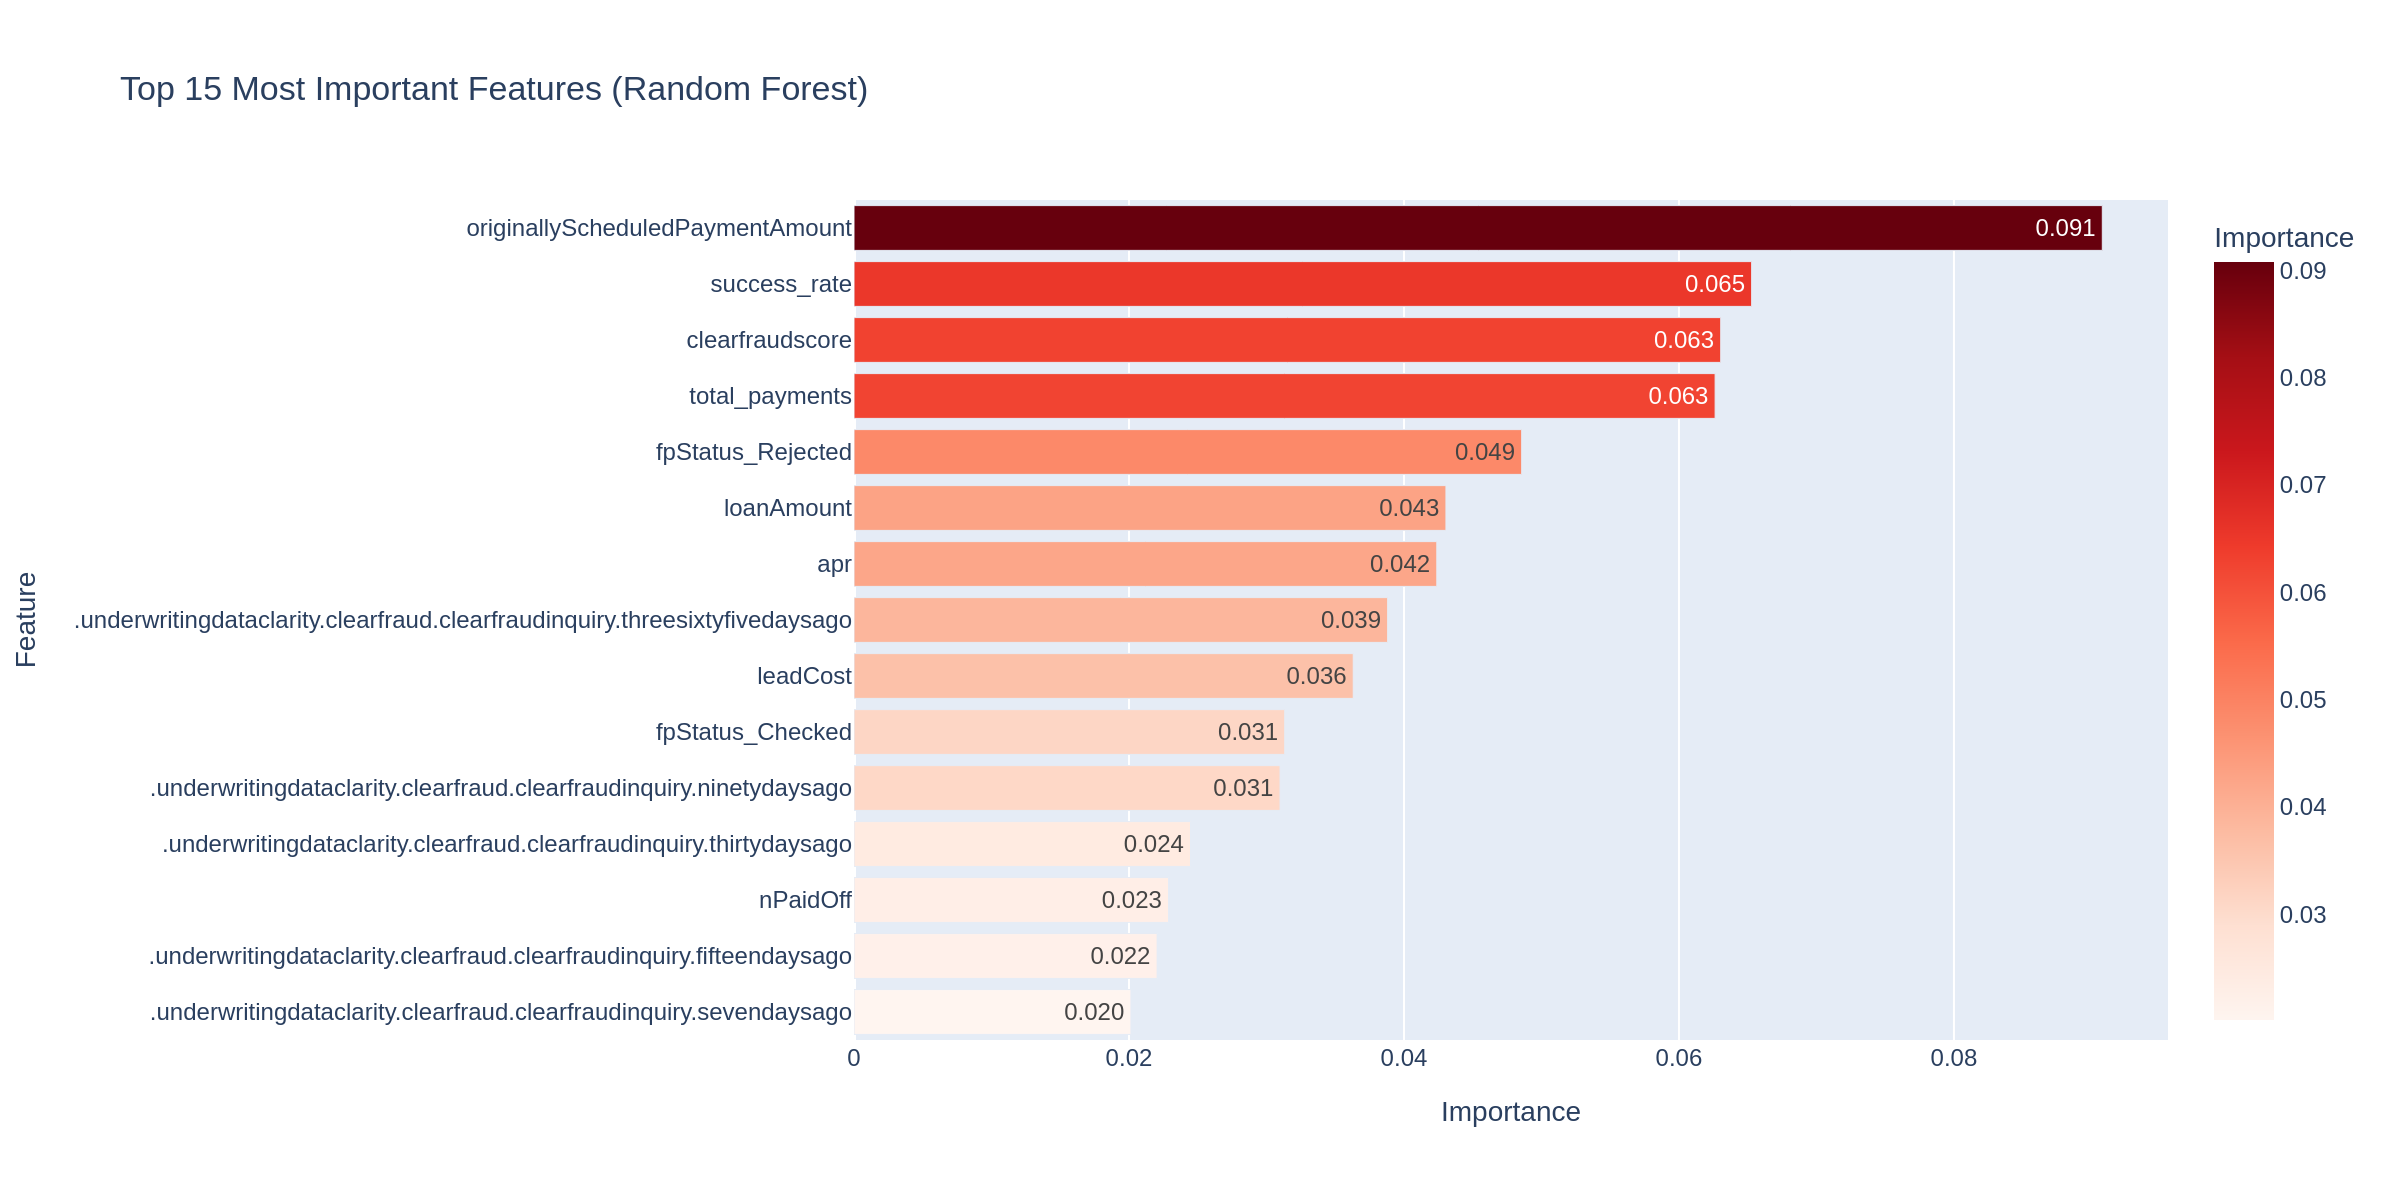

In [ ]:
#Create chart
fig_fi = px.bar(
    feature_importances.sort_values('Importance', ascending=True),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 15 Most Important Features (Random Forest)',
    color='Importance',
    color_continuous_scale='Reds',
    text_auto='.3f'
)

#fig_fi.show()
show_chart(fig_fi)

**Key Finding:** *The total scheduled payment amount is the strongest predictor (9.1%), followed by payment success rate and fraud score (both ~6.3%). More importantly, two of the top four features `success_rate` and `total_payments` were engineered from the payment dataset, confirming that payment behaviour history is a powerful signal for predicting repayment.*

###Correlation Matrix

*How features relate to each other*

In [ ]:
#Top 15 features for target correlatin
top_features = feature_importances['Feature'].tolist()

In [ ]:
#Original columns names
top_feature_cols = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False).head(15)['Feature'].tolist()

In [ ]:
#Correlation matrix
corr_data = df_model[top_feature_cols + ['loan_repaid']].corr()

#Clean column names
clean_names = [col.split('.')[-1] for col in corr_data.columns]

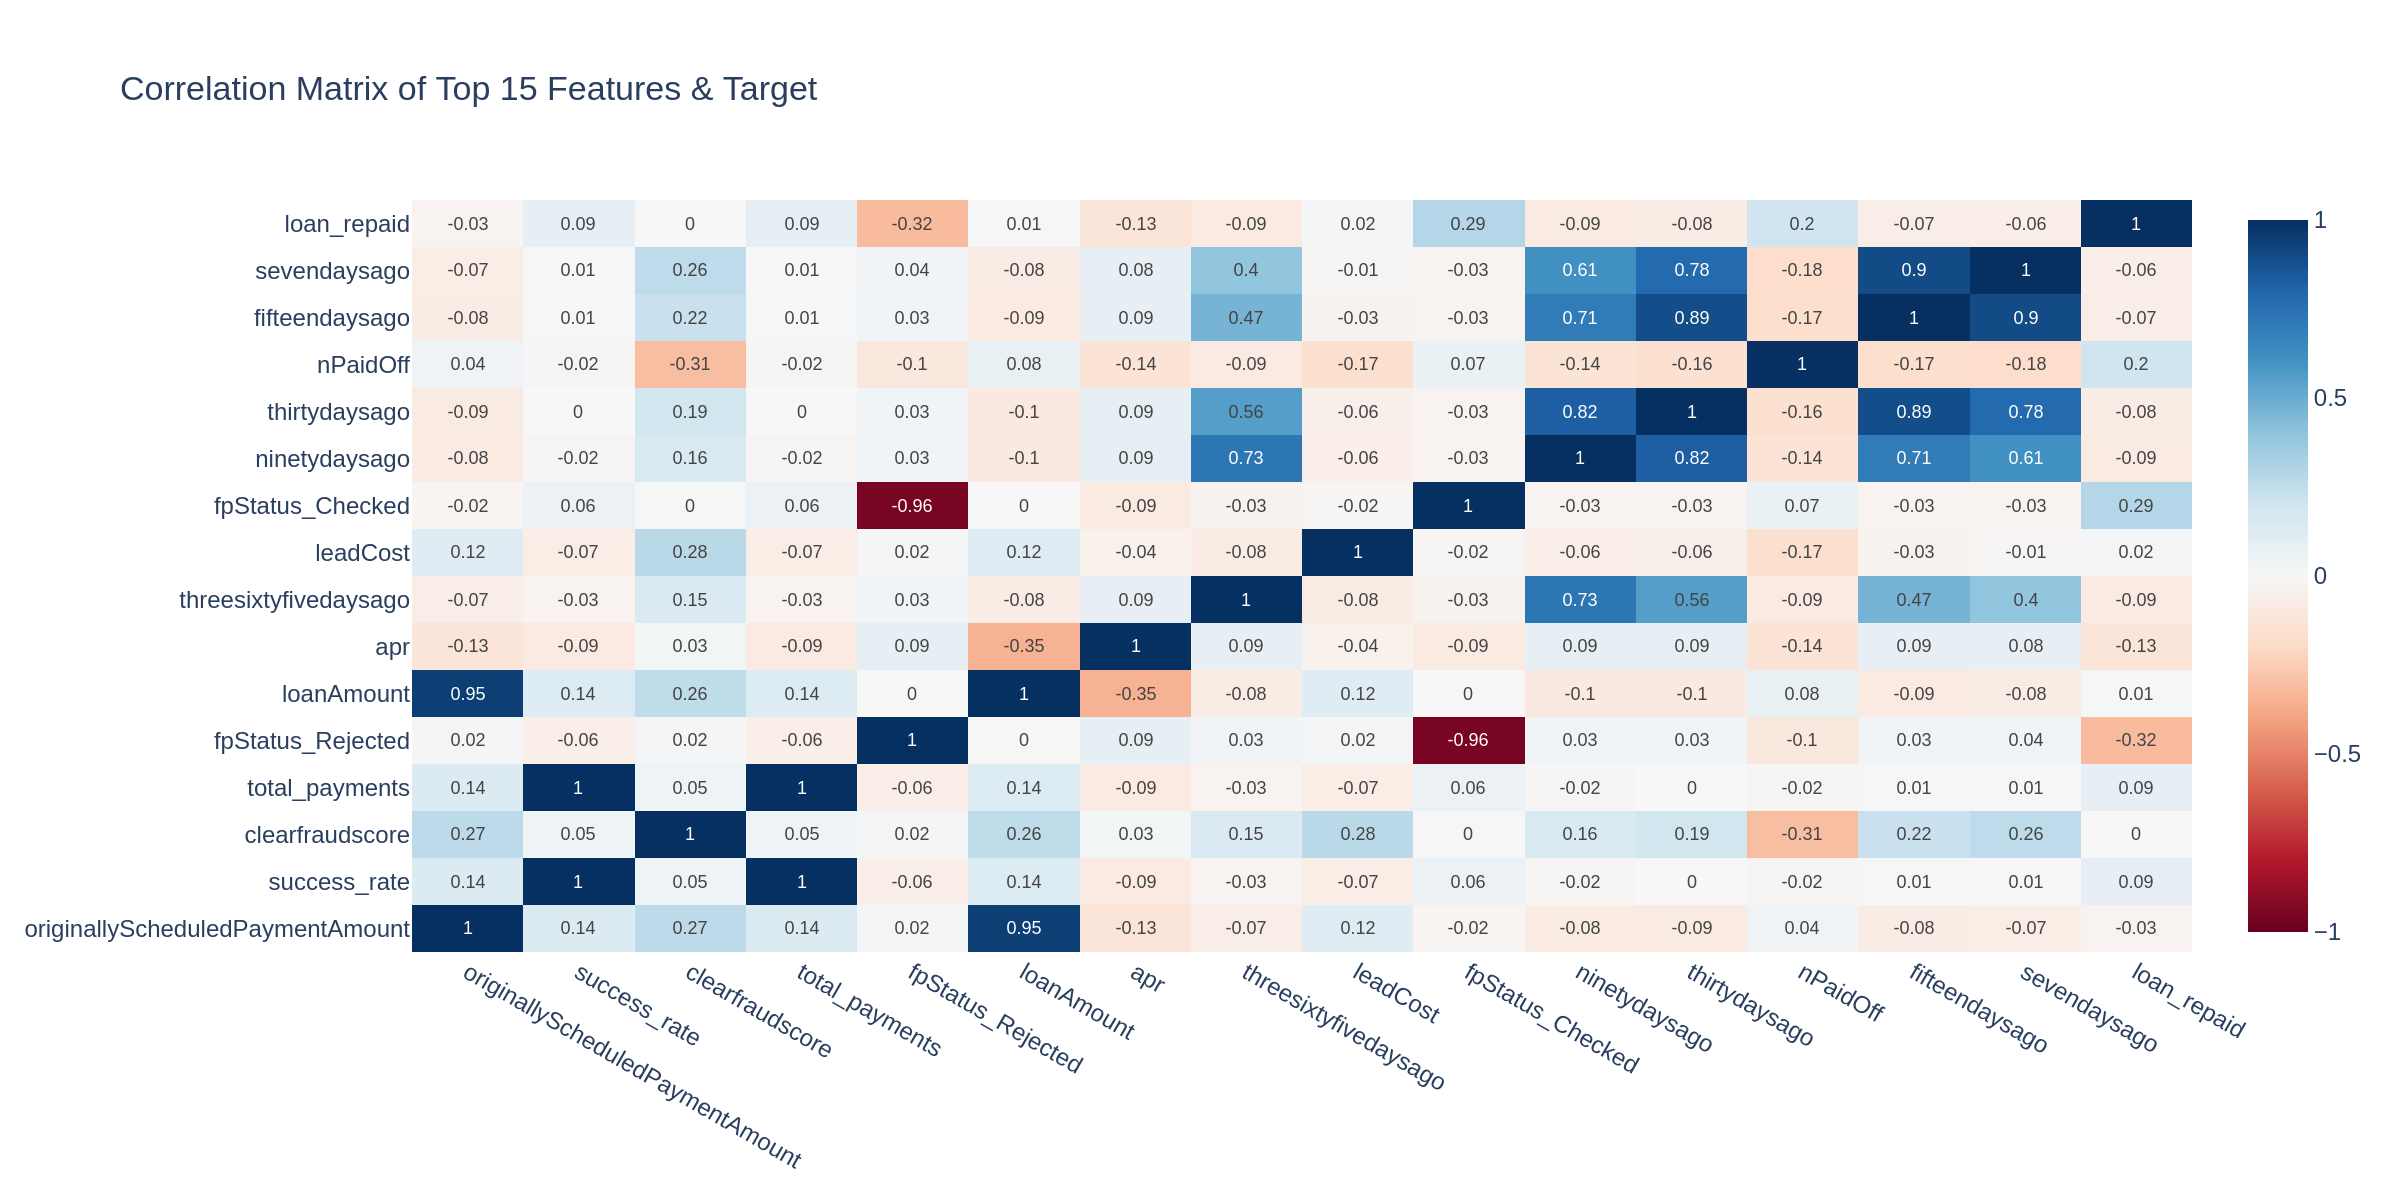

In [ ]:
#Create heatmap
fig_corr = go.Figure(data=go.Heatmap(
    z=corr_data.values,
    x=clean_names,
    y=clean_names,
    colorscale='RdBu',
    zmid=0,
    text=corr_data.round(2).values,
    texttemplate='%{text}',
    textfont=dict(size=9)
))

fig_corr.update_layout(
    title='Correlation Matrix of Top 15 Features & Target',
    height=600
)

#fig_corr.show()
show_chart(fig_corr)

**Key Finding:** *`fpStatus_Checked` and `fpStatus_Rejected` show a near-perfect negative correlation (-0.96) as expected, since they are opposites. `loanAmount` and `originallyScheduledPaymentAmount` are almost perfectly correlated (0.95), meaning larger loans always come with larger scheduled repayments. The clarity inquiry columns (7-day, 15-day, 30-day) are also highly correlated with  each other, suggesting they carry similar information.*

###Confusion Matrix Heatmap

*Where the model (Random Forest) makes mistakes*

In [ ]:
#Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

In [ ]:
#Labels
labels = ['Bad Loans (0)', 'Good Loans (1)']

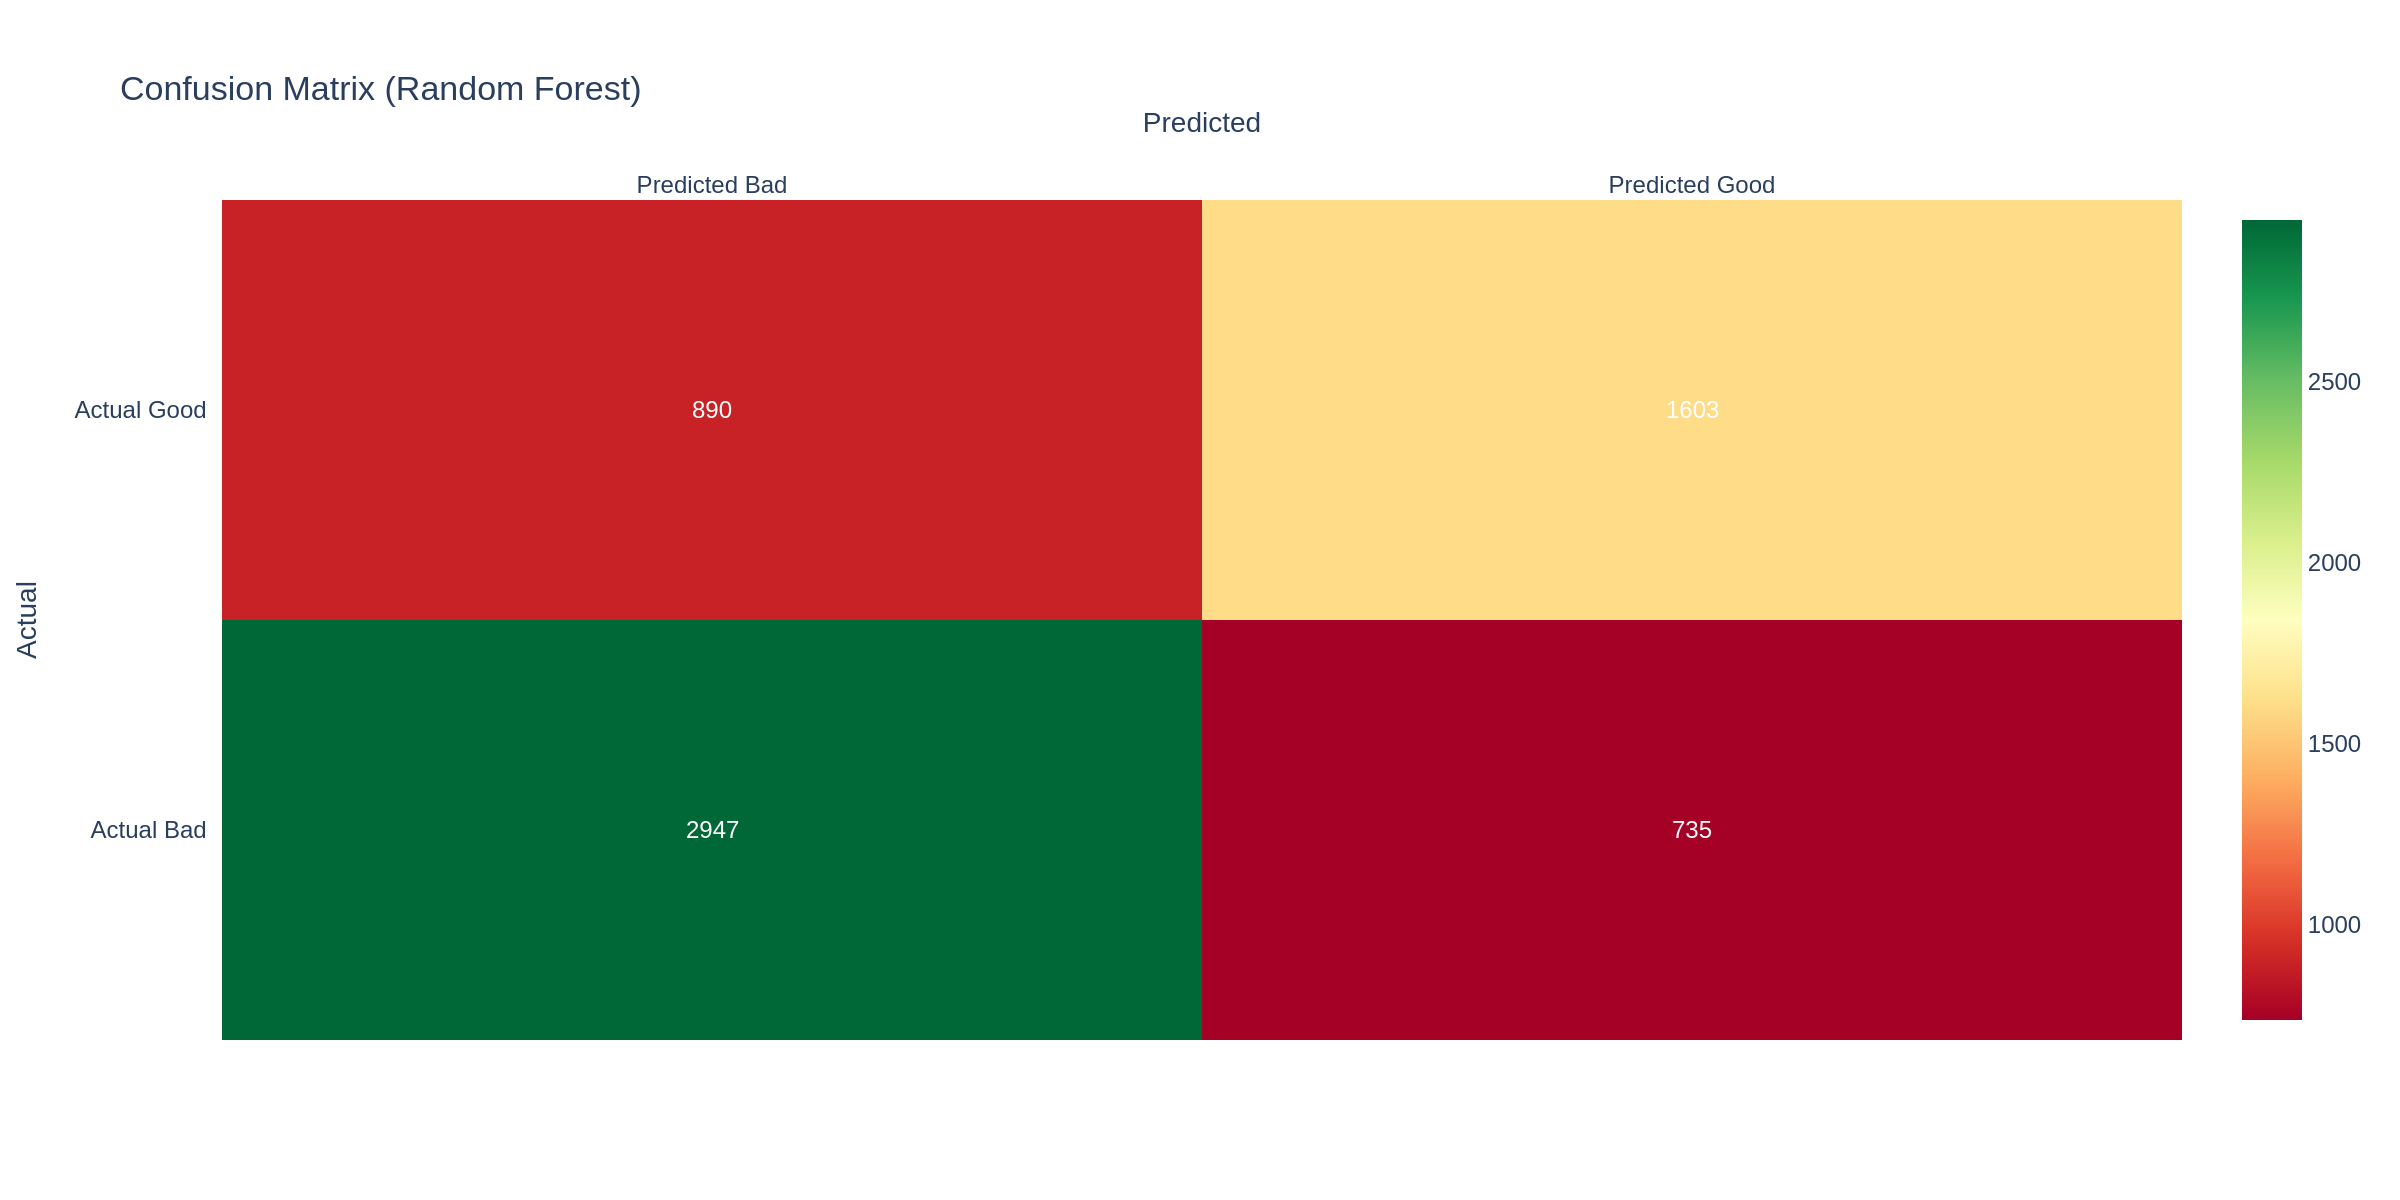

In [ ]:
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=['Predicted Bad', 'Predicted Good'],
    y=['Actual Bad', 'Actual Good'],
    colorscale="RdYlGn",
    showscale=True,
    annotation_text=cm
)

fig_cm.update_layout(
    title='Confusion Matrix (Random Forest)',
    xaxis_title='Predicted',
    yaxis_title='Actual'
)

#fig_cm.show()
show_chart(fig_cm)

**Key Finding:** *Out of 3,682 actual bad loans, the model correctly flagged 2,947 (80%), meaning only 735 bad loans slipped through undetected. Out of 2,493 actual good loans, 1,603 (64%) were correctly approved, while 890 good loans were wrongly flagged as risky. For a loan repayment, catching bad loans matters most and the model does this very well.*

###ROC Curve

*Model quality comparison*

In [ ]:
#ROC curve values for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model_scaled.predict_proba(X_test_scaled)[:, 1]) #Logistic Regression (scaled model)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1]) #Random Forest

In [ ]:
#Create chart
fig_roc = go.Figure()

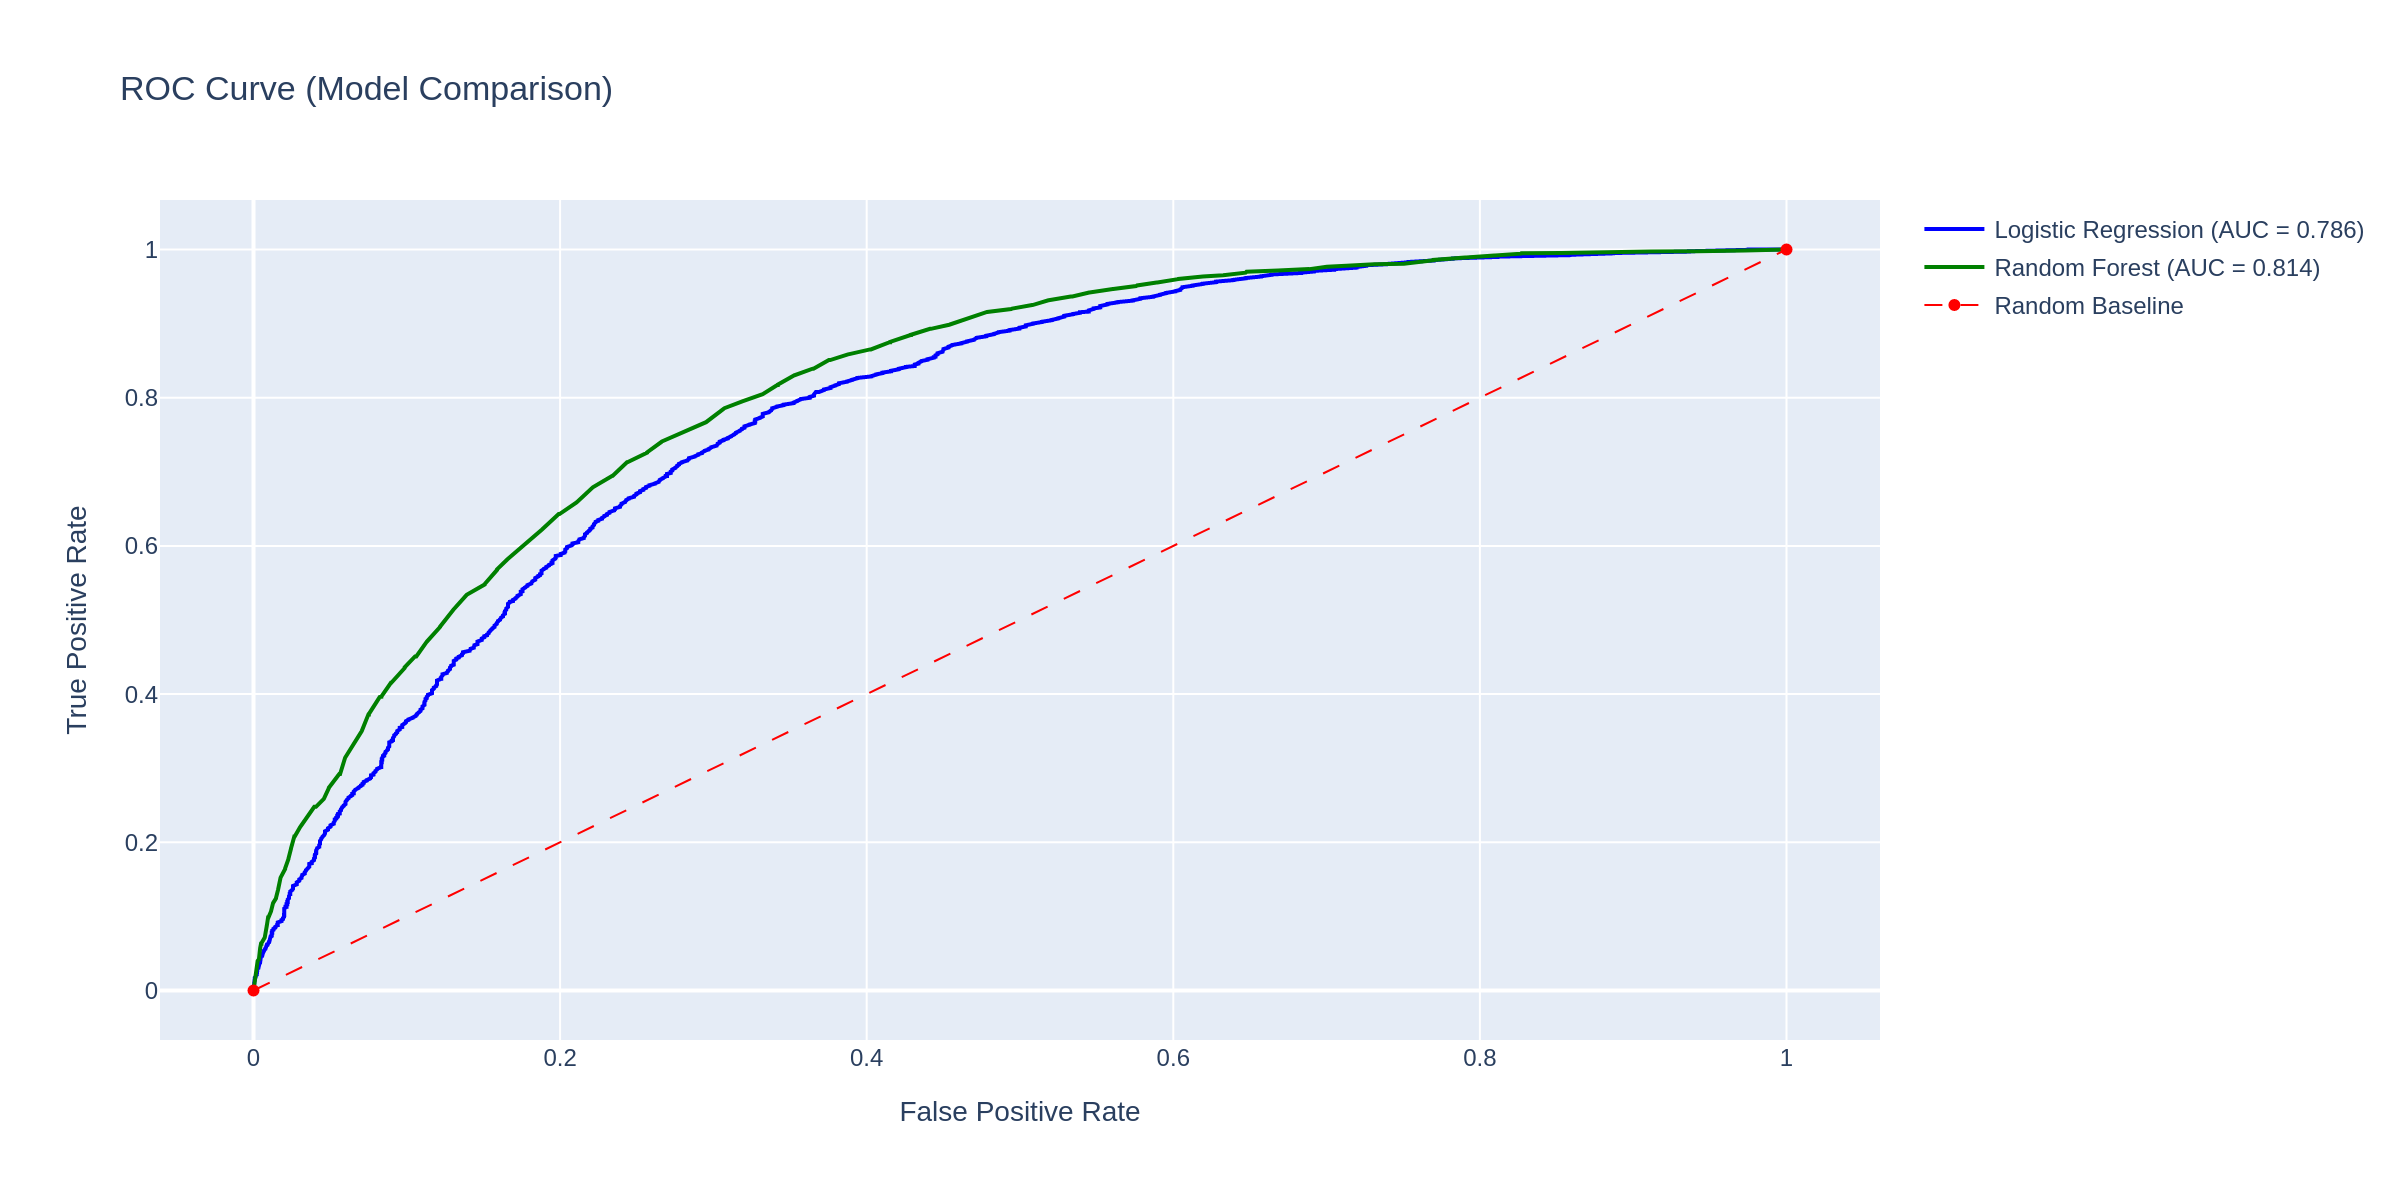

In [ ]:
#Add Logistic Regression line
fig_roc.add_trace(go.Scatter(
    x=fpr_lr,
    y=tpr_lr,
    name=f'Logistic Regression (AUC = 0.786)',
    line=dict(color='blue', width=2)
))

#Add Random Forest line
fig_roc.add_trace(go.Scatter(
    x=fpr_rf,
    y=tpr_rf,
    name=f'Random Forest (AUC = 0.814)',
    line=dict(color='green', width=2)
))

#Add random baseline
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    name='Random Baseline',
    line=dict(color='red', width=1, dash='dash')
))

fig_roc.update_layout(
    title='ROC Curve (Model Comparison)',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate'
)

#fig_roc.show()
show_chart(fig_roc)

**Key Finding:** *Both models significantly outperform random guessing (the red dashed baseline). Random Forest (AUC = 0.814) consistently performs above Logistic Regression (AUC = 0.786) across all thresholds, confirming it as the stronger model. The steep early rise of both curves shows the models are particularly good at catching bad loans.*

###Model Comparison

*Side by side performance of models*

In [ ]:
#Comparison data
comparison_data = {
    'Metric' : ['Accuracy', 'AUC-ROC', 'Bad Loan Recall', 'Good Loan Recall'],
    'Logistic Regression' : [71, 78.6, 79, 60],
    'Random Forest' : [74, 81.4, 80, 64]
}

df_comparison = pd.DataFrame(comparison_data)

In [ ]:
df_melted = df_comparison.melt(
    id_vars='Metric',
    var_name='Model',
    value_name='Score'
)

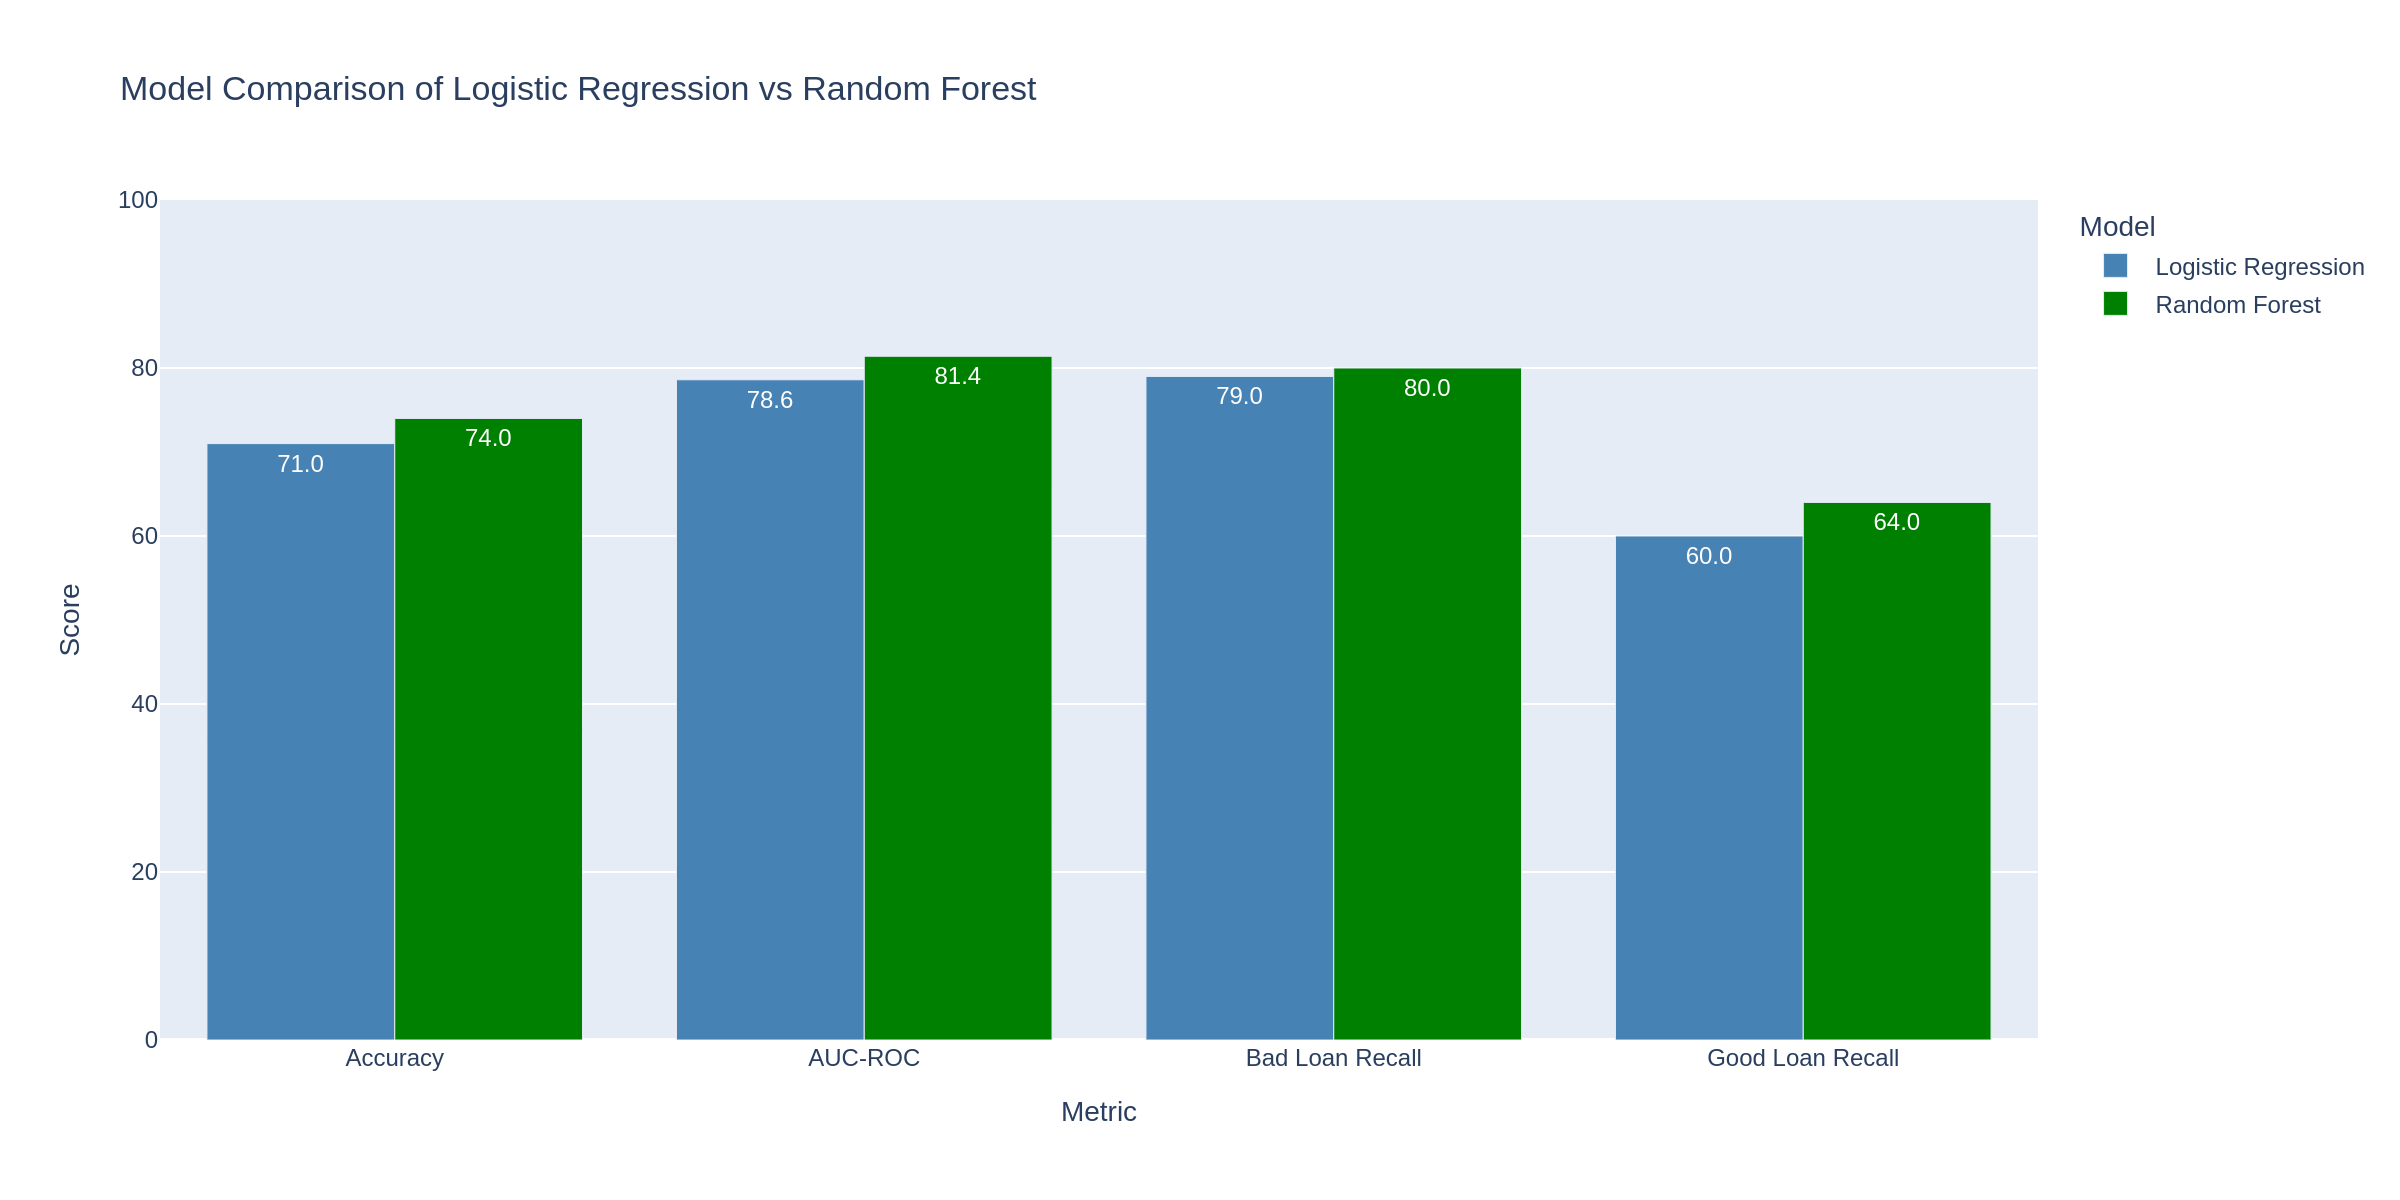

In [ ]:
#Create bar chart
fig_comp = px.bar(
    df_melted,
    x='Metric',
    y='Score',
    color='Model',
    barmode='group',
    title='Model Comparison of Logistic Regression vs Random Forest',
    color_discrete_map={
        'Logistic Regression': 'steelblue',
        'Random Forest': 'green'
    },
    text_auto='.1f'
)

fig_comp.update_layout(yaxis_range=[0,100])

#fig_comp.show()
show_chart(fig_comp)

**Key Finding:** *Random Forest outperforms Logistic Regression across every single metric such as having higher accuracy (74% vs 71%), better AUC-ROC (81.4 vs 78.6), stronger bad loan recall (80% vs 79%) and better good loan recall (64% vs 60%). Random Forest is selected as the final production model.*

# 5) Key Findings & Recommendations

**What indicators predicts loan repayment most strongly:**

1. **Total scheduled payment amount** *(larger obligations lead to more defaults)*
2. **Payment success rate** *(borrowers with consistent payment history are far less risky)*
3. **Total payments made** *(more payment attempts signals an active repayment journey)*
4. **First payment status** *(if the first payment fails, the loan is very likely to default)*
5. **Fraud score** *(third-party risk signals are strong predictors)*

**Recommendations for MoneyLion:**

- Prioritise applicants with a proven payment history like returning/repeat customers
- Flag applications where the first payment fails immediately for review
- Be cautious with high loan amounts relative to payment capacity
- Invest in clarity underwriting checks for all applicants as the data from background checks significantly improves prediction
- Consider weekly-payment borrowers as higher risk and price accordingly

**Model chosen:**

- Random Forest *(74% accuracy, AUC-ROC of 0.814, catches 80% of bad loans before money is lost which is more important as the bottomline for MoneyLion)*

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/MoneyLion_LoanRepayment.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/MoneyLion_LoanRepayment.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 3917034 bytes to /content/drive/MyDrive/Colab Notebooks/MoneyLion Assessment/MoneyLion_LoanRepayment.html
